# Who Earned the Credit? Splitting MMM Channel Impact Across Campaigns

> *Splitting a channel's Marketing Mix Model impact across campaigns, using a 100-year-old idea from insurance*

Your Marketing Mix Model has done its job. It tells you, with honest uncertainty, that **Paid Social drove this much incremental revenue**, day by day. You bring it to the review, and the first question is the one the MMM cannot answer:

> *"Which campaign?"*

So you open the platform dashboard. Every campaign is proudly claiming conversions. Add them up and they total far more than the MMM says the whole channel earned. The always-on brand campaign looks steady, a weekend burst commands attention, a tiny niche campaign swings from hero to flop week to week, and the broad prospecting push that only launched in April has barely four weeks of history to its name. On top of that, most of those platform conversions are rule-based and **non-incremental**: plenty of those people would have converted anyway.

Strip the noise away and the problem is simple. You have **one number you trust** (the MMM's channel total) and **seven shaky signals** (the per-campaign platform numbers). The question is not *whether* to use the shaky signals, because they are all you have. It is **how much to believe each one**.

:::{admonition} The old idea we are going to borrow
:class: tip
This is exactly the problem an insurance actuary solves before breakfast.

Picture pricing car insurance. A driver comes in with **one** claim-free year. Do you give them the flawless-driver discount? Of course not, because one year is too little to tell skill from luck. So you **blend** their record with the average driver, and you lean on their own history more and more as it piles up:

$$\text{best guess}=Z\cdot(\text{their record})+(1-Z)\cdot(\text{average driver}),
\qquad Z=\frac{n}{n+k}.$$

That blend has a name, **credibility**, and a single dial, **Z**, that runs from 0 ("I will trust the average") to 1 ("I will trust you"). It turns on one thing: **how much evidence you have** ($n$), measured against a threshold $k$ that says how much evidence counts as "enough". A campaign that has reached exactly $k$ people is believed half-way; one that has reached far more than $k$ people is mostly believed; one that has reached far fewer is mostly replaced by the average.

In this notebook the threshold comes out at about 37,000 people, roughly the size of an average campaign here (the fitted value is reported exactly in Step 2). The campaign that reached 62,000 people ends up 61% believed, so we take most of its own story and fill the rest with the group average. The campaign that reached 18,000 ends up 34% believed, mostly the average until it earns more trust. Nobody is ignored, and nobody is blindly believed.
:::

**The whole idea of this notebook, in one sentence:** swap *"years of driving history"* for *"how many people the campaign reached"*, and use that dial to decide how much of each campaign's own story to believe. **Reach is evidence.**

What you get at the end is a per-campaign, per-day split of the MMM's channel credit that (a) always adds back up to the MMM total, (b) cannot be hijacked by small, loud campaigns, and (c) carries an uncertainty band you can defend in the budget meeting. To be upfront about the scale of the win: on this data the measurable gains are a better campaign ranking, better calibrated uncertainty and a trust weight you can justify, not a jump in point accuracy over a plain delivery split. The last section spells out what the method cannot do.

:::{admonition} Before you start
:class: note
**What you need.** A fitted PyMC-Marketing MMM whose posterior contains the channel contribution (`channel_contribution`, see the [MMM example notebook](mmm_example.ipynb)), the daily per-campaign export from the ad platform (spend, impressions, reach, clicks), and one extra report described in the data section: expanding-window unique reach.

**What you will do.** Three steps (build each campaign's noisy own story, let the data set the trust dial, hand the MMM's daily credit back to the campaigns), then grade the result against a hidden truth, extend it with the MMM's own carryover, and stress-test it three ways before reading the limits.

**What it costs.** About fifteen small PyMC fits of a seven-row model. A few minutes on a laptop.

**The data.** Everything here is synthetic. A ground-truth file of per-campaign contributions is loaded alongside the inputs and used **only** to grade the result at the end, never to fit anything.
:::

:::{dropdown} For the statistically minded: the exact mapping
This is **Bühlmann credibility**, which blends a policyholder's own experience with the collective mean,
$$\text{premium}=Z\cdot(\text{own})+(1-Z)\cdot(\text{collective}),\qquad Z=\frac{n}{n+k},$$
and it is exactly hierarchical-Bayes partial pooling.

An actuary routinely uses one quantity to scale the premium and a different one to set the credibility weight, and that is what happens here. A person re-reached on a second day adds delivery volume but no new information about the campaign, so **reach-days** carry the exposure and **unique people reached** carry the evidence.

| Bühlmann credibility (actuarial) | This MMM disaggregation |
|---|---|
| Policyholder | Campaign $c$ |
| Portfolio, the *collective* | The whole social channel |
| Own loss experience (noisy) | Naive contribution per reach-day (social split by click share) |
| Earned exposure, in policy-years | **Reach-days** $R_c=\sum_t \text{reach}_{ct}$, the volume the credit is spent over |
| Volume measure that sets credibility | **Unique people reached** $n_c$, from the expanding-window query |
| Loss per unit exposure | Contribution per reach-day |
| Collective mean | Channel-average log-effectiveness $\mu$ |
| Credibility factor $Z_c=\frac{n_c}{n_c+k}$ | Trust in a campaign's own signal |
| Credibility premium | Trust-adjusted rate per reach-day, spent over daily reach-days |

Writing the direct estimate's sampling variance as $\psi_c=s^2/n_c$,
$$Z_c=\frac{n_c}{n_c+k}=\frac{\tau^2}{\tau^2+\psi_c},$$
which is one minus the shrinkage factor of a Fay-Herriot small-area model, with the sampling variances tied to reach rather than supplied by hand.
:::

In [1]:
import warnings
from dataclasses import dataclass

import arviz as az
import arviz_plots as azp
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import pytensor.xtensor as ptx
import seaborn as sns
import xarray as xr
from IPython.display import display
from scipy.stats import norm, spearmanr

from pymc_marketing.metrics import crps, per_observation_crps
from pymc_marketing.mmm.transformers import geometric_adstock
from pymc_marketing.paths import data_dir

# Cosmetic warnings only: progress-bar widgets when ipywidgets is missing, and a
# seaborn/matplotlib deprecation that is out of our hands.
warnings.filterwarnings("ignore", message="IProgress not found")
warnings.filterwarnings("ignore", message='install "ipywidgets" for Jupyter support')
warnings.filterwarnings(
    "ignore",
    message="vert: bool will be deprecated",
    category=PendingDeprecationWarning,
)

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"
az.rcParams["stats.ci_kind"] = "hdi"
az.rcParams["stats.ci_prob"] = 0.94

CI_PROB = az.rcParams["stats.ci_prob"]
seed = 42
rng: np.random.Generator = np.random.default_rng(seed=seed)

Before touching any data, here is the whole method in one picture. The trust dial $Z$ rises with the number of people a campaign has reached, and the threshold $k$ decides how fast: at $n = k$ a campaign is believed exactly half-way. Everything that follows is about measuring $n$ properly, letting the data choose $k$, and then spending the MMM's credit according to the resulting blend.

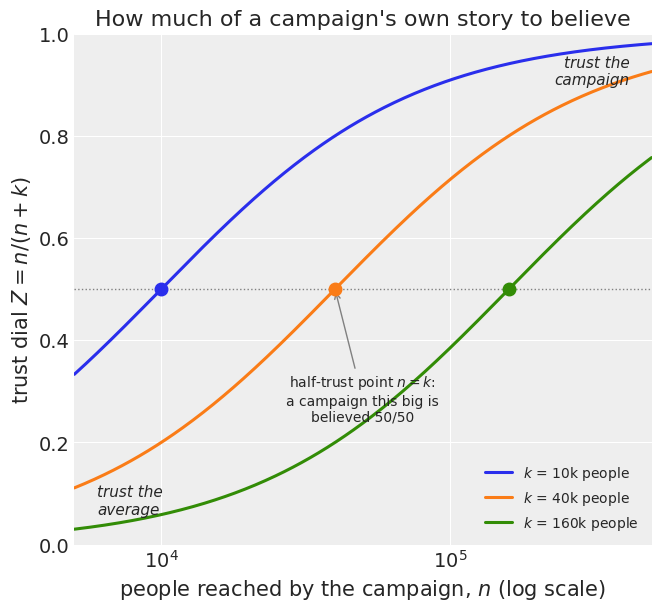

In [2]:
people_grid = np.geomspace(5e3, 5e5, 400)

fig, ax = plt.subplots(figsize=(6.5, 6), layout="constrained")
for threshold, color in zip((10_000, 40_000, 160_000), ("C0", "C1", "C2"), strict=True):
    ax.plot(
        people_grid,
        people_grid / (people_grid + threshold),
        color=color,
        lw=2.2,
        label=f"$k$ = {threshold / 1e3:.0f}k people",
    )
    ax.plot(threshold, 0.5, "o", color=color, ms=9, zorder=4)
ax.axhline(0.5, ls=":", color="gray", lw=1)
ax.annotate(
    "half-trust point $n = k$:\na campaign this big is\nbelieved 50/50",
    (40_000, 0.5),
    xytext=(20, -95),
    textcoords="offset points",
    ha="center",
    fontsize=10,
    arrowprops={"arrowstyle": "->", "color": "gray"},
)
ax.text(6e3, 0.06, "trust the\naverage", fontsize=11, ha="left", style="italic")
ax.text(4.2e5, 0.90, "trust the\ncampaign", fontsize=11, ha="right", style="italic")
ax.set(
    xscale="log",
    xlim=(5e3, 5e5),
    ylim=(0, 1),
    xlabel="people reached by the campaign, $n$ (log scale)",
    ylabel="trust dial $Z = n / (n + k)$",
    title="How much of a campaign's own story to believe",
)
_ = ax.legend(loc="lower right", fontsize=10)

> **Fig.** The credibility dial. Each curve is one value of the evidence threshold $k$; the dot marks the half-trust point where a campaign has reached exactly $k$ people. Small campaigns sit on the left and are mostly replaced by the group average, large ones sit on the right and are mostly believed. Step 2 fits $k$ from the data and puts the seven real campaigns on this curve.

## Load the data

Seven campaigns ran on one social channel across a 120-day window: six veterans plus a broad prospecting push that only kicked off on April 1st. We load five inputs and one grading file:

- `credibility_campaign_daily_metrics.csv`: the everyday delivery export any analyst has, one row per campaign per day with spend, impressions, reach and clicks.
- `credibility_campaign_cumulative_reach.csv`: the expanding-window unique reach per campaign, a second report explained in the data section below.
- `credibility_audience_overlap_matrix.csv`: the pairwise audience-overlap matrix between campaigns.
- `credibility_mmm_input_data.csv`: the dates the MMM was fit on.
- `credibility_channel_contribution_posterior.nc`: the **MMM's social-contribution posterior**, the full range of plausible values for the channel's daily impact rather than a point estimate. That posterior is the trustworthy number we are going to divide up. In your own work this is `mmm.idata.posterior["channel_contribution"]` selected on the channel.
- `credibility_ground_truth_campaign_contributions.csv`: the simulated ground truth, used **only** at the end to grade our work, never to fit.

In [3]:
@dataclass
class CampaignData:
    """Delivery telemetry, the MMM social posterior, and the held-out ground truth."""

    metrics: pd.DataFrame
    cum_reach: pd.DataFrame
    overlap: pd.DataFrame
    mmm: pd.DataFrame
    social: xr.DataArray
    truth: pd.DataFrame  # oracle, used only for grading

    @property
    def campaigns(self) -> list[str]:
        """Campaign names, in the order reported by the expanding-window query."""
        return list(self.cum_reach.columns)


def load_campaign_data() -> CampaignData:
    """Read the campaign telemetry, the MMM social posterior, and the ground truth."""
    contribution = xr.open_dataset(
        data_dir / "credibility_channel_contribution_posterior.nc"
    )["channel_contribution"]
    return CampaignData(
        metrics=pd.read_csv(
            data_dir / "credibility_campaign_daily_metrics.csv", parse_dates=["date"]
        ),
        cum_reach=pd.read_csv(
            data_dir / "credibility_campaign_cumulative_reach.csv",
            index_col=0,
            parse_dates=True,
        ),
        overlap=pd.read_csv(
            data_dir / "credibility_audience_overlap_matrix.csv", index_col=0
        ),
        mmm=pd.read_csv(
            data_dir / "credibility_mmm_input_data.csv", parse_dates=["date"]
        ),
        social=contribution.sel(channel="social"),
        truth=pd.read_csv(
            data_dir / "credibility_ground_truth_campaign_contributions.csv",
            index_col=0,
            parse_dates=True,
        ),
    )


data = load_campaign_data()
campaigns = data.campaigns
colors = {campaign: f"C{i}" for i, campaign in enumerate(campaigns)}
channel_total = float(data.social.sum("date").mean())

print(
    f"{len(campaigns)} campaigns, {data.metrics['date'].nunique()} days from "
    f"{data.metrics['date'].min():%Y-%m-%d} to {data.metrics['date'].max():%Y-%m-%d}.\n"
    f"MMM social contribution over the window: {channel_total:,.0f} "
    "(posterior mean of the total)."
)

7 campaigns, 120 days from 2025-01-01 to 2025-04-30.
MMM social contribution over the window: 281,777 (posterior mean of the total).


## Exploratory data analysis

### The data you already have

Every ad platform, and its reporting API, hands you a table like this: one row per campaign per day, with delivery, attention, and cost. Here is one mid-flight day in February, when six of the seven campaigns are live.

In [4]:
platform_export = (
    data.metrics.loc[
        data.metrics["impressions"] > 0,
        ["date", "campaign", "reach", "impressions", "clicks", "spend"],
    ]
    .assign(
        ctr_pct=lambda df: (100 * df["clicks"] / df["impressions"]).round(2),
        cpm=lambda df: (1000 * df["spend"] / df["impressions"]).round(2),
    )
    .drop(columns="spend")
)
mid_flight = sorted(data.metrics["date"].unique())[55]
platform_export.query("date == @mid_flight").reset_index(drop=True)

,date,campaign,reach,impressions,clicks,ctr_pct,cpm
0,2025-02-25,brand_always_on,13911,26919,408,1.52,13.43
1,2025-02-25,spring_promo,9437,18430,371,2.01,15.00
2,2025-02-25,lookalike_conversions,3386,4006,70,1.75,17.13
3,2025-02-25,video_product_launch,7426,14472,150,1.04,10.43
4,2025-02-25,flash_sale_burst,11227,41245,769,1.86,15.30
5,2025-02-25,niche_interest,1859,2342,52,2.22,19.26


Aggregated over each campaign's flight, the same export gives the summary any media report starts from. Two columns deserve care because the whole notebook turns on the difference between them:

- `reach_days` is the daily reach column summed over days. It counts the same person again every day the campaign touches them.
- `unique_reach` is the number of distinct people reached by the end of the window. It comes from a second report, the expanding-window query, which we explain a few cells down.

Their ratio, `reach_days_per_person`, is how many days the average reached person saw the campaign.

In [5]:
def campaign_totals(metrics: pd.DataFrame, campaigns: list[str]) -> pd.DataFrame:
    """Flight totals per campaign: clicks, impressions, spend, reach-days, active days."""
    return (
        metrics.groupby("campaign")
        .agg(
            clicks=("clicks", "sum"),
            impressions=("impressions", "sum"),
            spend=("spend", "sum"),
            reach_days=("reach", "sum"),
            active_days=("active", "sum"),
        )
        .reindex(campaigns)
    )


def final_unique_reach(cum_reach: pd.DataFrame, campaigns: list[str]) -> pd.Series:
    """Unduplicated people reached by the end of the window, the evidence measure."""
    return cum_reach.ffill().iloc[-1].reindex(campaigns).astype(float)


def campaign_summary(data: CampaignData) -> pd.DataFrame:
    """Flight-level delivery, cost and efficiency, one row per campaign."""
    totals = campaign_totals(data.metrics, data.campaigns)
    unique_reach = final_unique_reach(data.cum_reach, data.campaigns)
    return pd.DataFrame(
        {
            "active_days": totals["active_days"],
            "spend": totals["spend"],
            "impressions": totals["impressions"],
            "clicks": totals["clicks"],
            "reach_days": totals["reach_days"],
            "unique_reach": unique_reach,
            "ctr_%": 100 * totals["clicks"] / totals["impressions"],
            "cpm": 1000 * totals["spend"] / totals["impressions"],
            "cpc": totals["spend"] / totals["clicks"],
            "impressions_per_person": totals["impressions"] / unique_reach,
            "reach_days_per_person": totals["reach_days"] / unique_reach,
        }
    ).sort_values("unique_reach", ascending=False)


summary = campaign_summary(data)
summary.round(2)

,active_days,spend,impressions,clicks,reach_days,unique_reach,ctr_%,cpm,cpc,impressions_per_person,reach_days_per_person
brand_always_on,120,36945.66,2952795,40073,1541137,62386.0,1.36,12.51,0.92,47.33,24.70
lookalike_conversions,120,14175.89,825661,16891,597676,42733.0,2.05,17.17,0.84,19.32,13.99
spring_promo,66,9775.35,699815,15985,438462,41719.0,2.28,13.97,0.61,16.77,10.51
flash_sale_burst,15,5184.37,370310,10084,139620,34802.0,2.72,14.00,0.51,10.64,4.01
video_product_launch,71,11884.28,1064727,10628,519340,33427.0,1.00,11.16,1.12,31.85,15.54
broad_prospecting,30,283.05,33994,1294,32921,24140.0,3.81,8.33,0.22,1.41,1.36
niche_interest,120,6619.94,354716,7709,254475,17987.0,2.17,18.66,0.86,19.72,14.15


The seven campaigns are deliberately unalike: spend ranges from $283 to $37k, flights from 15 days to the full 120, CTR from 1.0% to 3.8%, and the average reached person saw `brand_always_on` on 25 different days but `broad_prospecting` on 1.4. That spread is what makes a single flat trust level indefensible: these campaigns simply do not carry the same amount of evidence.

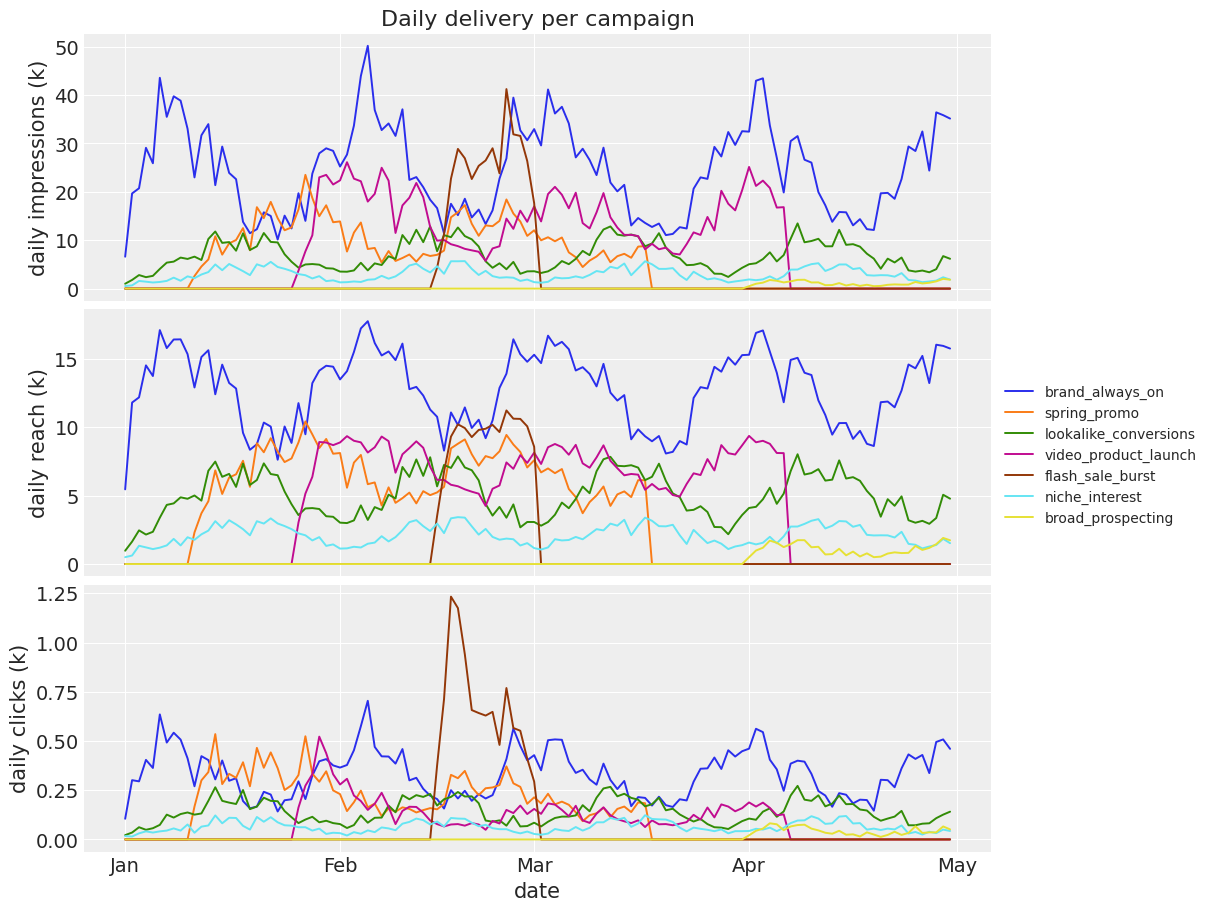

In [6]:
fig, axes = plt.subplots(
    nrows=3, ncols=1, sharex=True, figsize=(12, 9), layout="constrained"
)
for ax, column, label in zip(
    axes,
    ["impressions", "reach", "clicks"],
    ["daily impressions (k)", "daily reach (k)", "daily clicks (k)"],
    strict=True,
):
    wide = data.metrics.pivot(index="date", columns="campaign", values=column).reindex(
        columns=campaigns
    )
    for campaign in campaigns:
        ax.plot(
            wide.index,
            wide[campaign] / 1e3,
            color=colors[campaign],
            lw=1.4,
            label=campaign,
        )
    ax.set(ylabel=label)
axes[0].set(title="Daily delivery per campaign")
axes[-1].set(xlabel="date")
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b"))
_ = fig.legend(
    *axes[0].get_legend_handles_labels(),
    loc="outside center right",
    fontsize=10,
)

> **Fig.** Daily impressions, reach and clicks per campaign. The flight structure is visible: `brand_always_on`, `lookalike_conversions` and `niche_interest` run all 120 days, `spring_promo` and `video_product_launch` run in blocks, `flash_sale_burst` is a 15-day spike, and `broad_prospecting` only starts on April 1st. Reach and impressions move together within a campaign, which is the first hint that daily reach is a delivery measure rather than an audience measure.

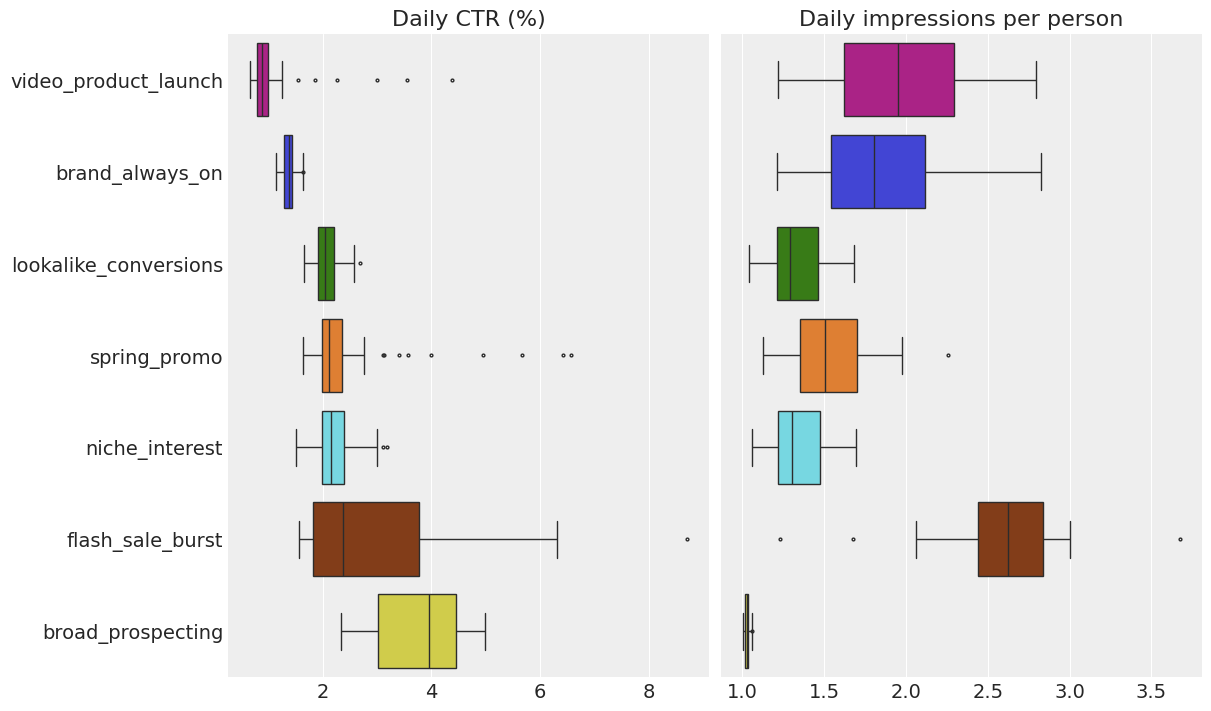

In [7]:
delivered = data.metrics.query("impressions > 0 and reach > 0").assign(
    ctr_pct=lambda df: 100 * df["clicks"] / df["impressions"],
    daily_frequency=lambda df: df["impressions"] / df["reach"],
)
order = delivered.groupby("campaign")["ctr_pct"].median().sort_values().index.tolist()
palette = [colors[campaign] for campaign in order]

fig, (ax_ctr, ax_freq) = plt.subplots(
    ncols=2, sharey=True, figsize=(12, 7), layout="constrained"
)
for ax, column, title in zip(
    [ax_ctr, ax_freq],
    ["ctr_pct", "daily_frequency"],
    ["Daily CTR (%)", "Daily impressions per person"],
    strict=True,
):
    sns.boxplot(
        data=delivered,
        x=column,
        y="campaign",
        order=order,
        hue="campaign",
        hue_order=order,
        palette=palette,
        legend=False,
        fliersize=2,
        ax=ax,
    )
    ax.set(title=title, xlabel="", ylabel="")

> **Fig.** Distribution over delivery days of each campaign's click-through rate and daily frequency, ordered by median CTR. Days with no impressions are excluded, since 298 of the 840 campaign-day cells carry no delivery. Two things matter for what follows. First, CTR differs by campaign by a factor of nearly four, so a click-share split is not a neutral allocation. Second, the small campaigns are the jumpy ones: `broad_prospecting` and `flash_sale_burst` have the widest day-to-day CTR spread, which is exactly the noisiness credibility is designed to discipline.

### The data you need, and how to build it

The export above is genuinely useful: **exposure** (reach, impressions), **attention** (clicks and CTR), and **cost** (CPM). It is also all most teams ever look at. For our question, who deserves the channel's credit, it has one blind spot that matters: **its `reach` is duplicated across days.** Summing the column gives impressions-flavoured volume, not people, so it cannot tell you when a campaign has **saturated its audience**, the point where more spend just re-hits the same faces. And "how many people has this campaign reached" is precisely the evidence measure the credibility dial needs.

Unduplicated audience growth is not a column you can export directly, but you can build it from the same platform or API with a particular **query pattern** and no extra tracking. Call it the **expanding window**. Do not pull one report of daily reach. Pull a *series* of reports where you fix the start date and push the **end** date out one day at a time: `[start to day 0]`, then `[start to day 1]`, then `[start to day 2]`, through `[start to day N]`. The platform de-duplicates *within* each report, so each one is the true unique reach so far, and the **difference between consecutive reports is the count of genuinely new people** reached that day. Stitch them together and you get a clean audience-growth curve instead of a duplicated daily count.

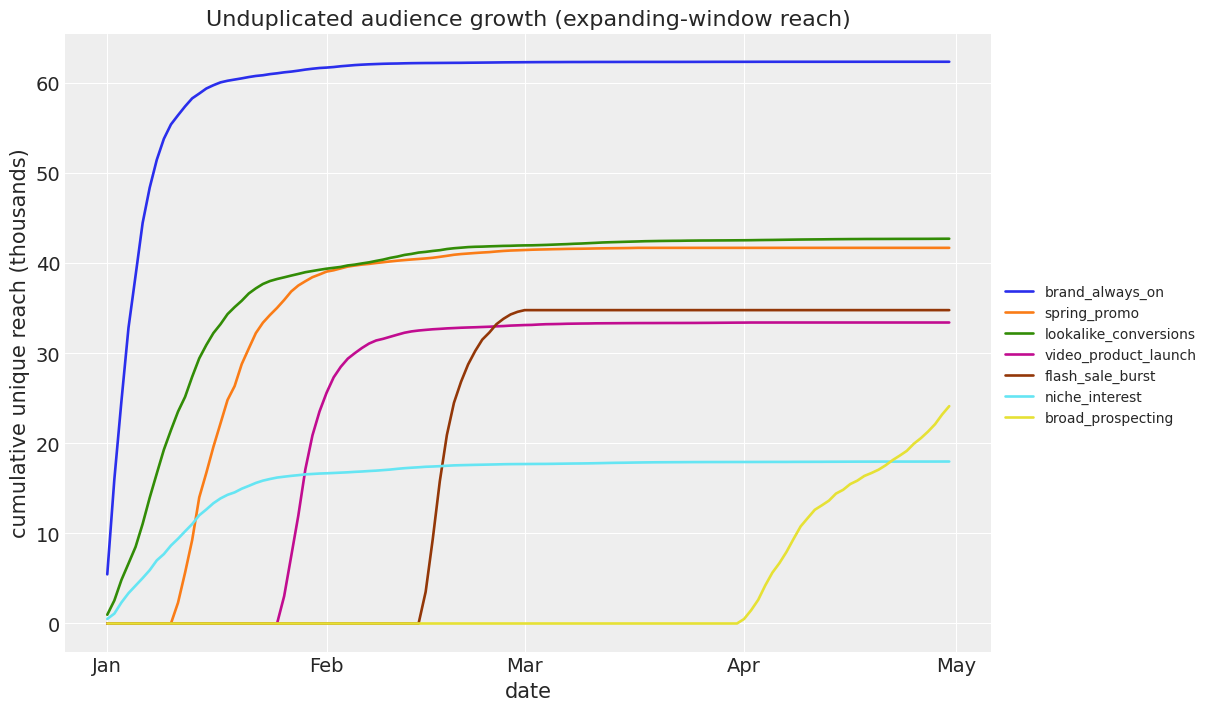

In [8]:
fig, ax = plt.subplots(figsize=(12, 7), layout="constrained")
for campaign in campaigns:
    ax.plot(
        data.cum_reach.index,
        data.cum_reach[campaign] / 1e3,
        lw=1.9,
        color=colors[campaign],
        label=campaign,
    )
ax.set(
    title="Unduplicated audience growth (expanding-window reach)",
    xlabel="date",
    ylabel="cumulative unique reach (thousands)",
)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
_ = fig.legend(loc="outside center right", fontsize=10)

> **Fig.** The expanding-window result: cumulative unique reach per campaign. Most curves are C-shaped, steep while the campaign keeps finding new people and then flattening as it exhausts its audience, and that flattening point is the audience saturation the raw daily table cannot reveal. Scales differ enormously, from `brand_always_on` saturating near 62k unique users to `niche_interest` near 18k. The exception is `broad_prospecting`: it launched on April 1st against a very large audience and is still climbing when the window closes, so it has no saturation knee, just a truncated growth curve.

Put the two reach numbers side by side and the difference is stark.

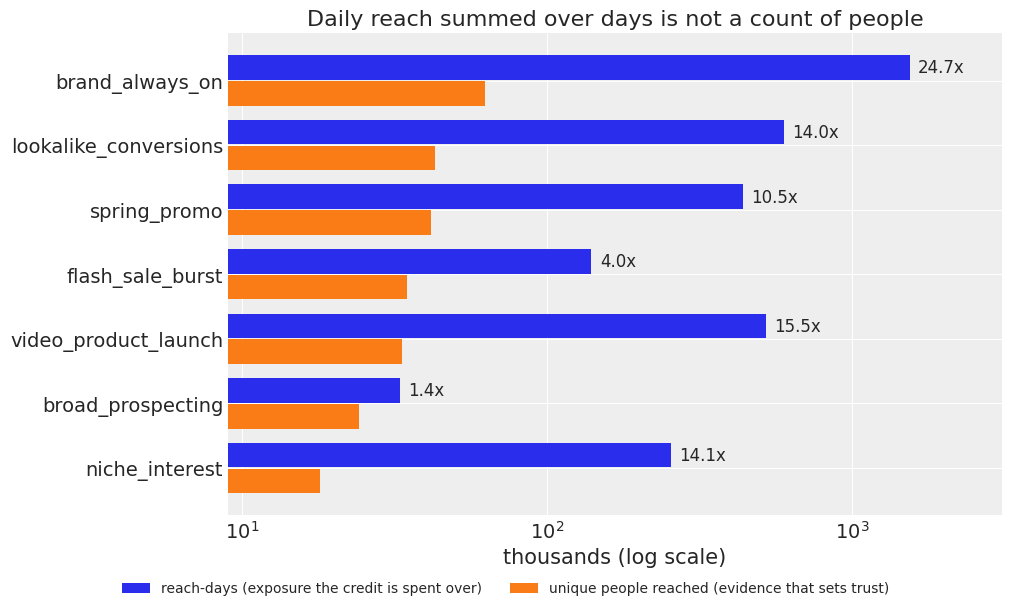

In [9]:
volume = pd.DataFrame(
    {
        "reach_days": campaign_totals(data.metrics, campaigns)["reach_days"],
        "unique_reach": final_unique_reach(data.cum_reach, campaigns),
    }
).sort_values("unique_reach")
thousands = volume / 1e3
positions = np.arange(len(volume))

fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")
ax.barh(
    positions + 0.2,
    thousands["reach_days"],
    height=0.38,
    color="C0",
    label="reach-days (exposure the credit is spent over)",
)
ax.barh(
    positions - 0.2,
    thousands["unique_reach"],
    height=0.38,
    color="C1",
    label="unique people reached (evidence that sets trust)",
)
for position, (reach_days, unique_reach) in enumerate(volume.to_numpy()):
    ax.annotate(
        f"{reach_days / unique_reach:.1f}x",
        (reach_days / 1e3, position + 0.2),
        xytext=(6, 0),
        textcoords="offset points",
        va="center",
        fontsize=12,
    )
# leave room on the right for the ratio annotations, and never clip a bar
ax.set(
    xscale="log",
    xlim=(thousands.to_numpy().min() / 2, thousands.to_numpy().max() * 2),
    yticks=positions,
    yticklabels=volume.index,
    xlabel="thousands (log scale)",
    title="Daily reach summed over days is not a count of people",
)
_ = fig.legend(loc="outside lower center", ncol=2, fontsize=10)

> **Fig.** Reach-days against unique people reached, with their ratio annotated. The gap runs from 1.4x for `broad_prospecting`, which barely revisits anyone, to 24.7x for `brand_always_on`, which spends most of its delivery re-reaching people it already has. Summing the daily reach column therefore measures delivery volume, not audience size.

:::{admonition} Two quantities, kept apart
:class: important
The rest of the notebook uses these two words in exactly one sense each, because conflating them is the easiest way to get the arithmetic wrong.

- **Unique reach** $n_c$, from the expanding-window query, is the **evidence**. It enters the trust dial $Z_c$ and nothing else.
- **Reach-days** $\text{reach}_{ct}$, summing to $R_c$, are the **exposure base**. They set the denominator of the rate we model and they spend that rate back out, day by day.

A person reached again tomorrow adds one reach-day but no new evidence about the campaign. The robustness checks at the end put this choice to the test by swapping the two.
:::

### The number we trust

The last input is the MMM's answer for the channel as a whole.

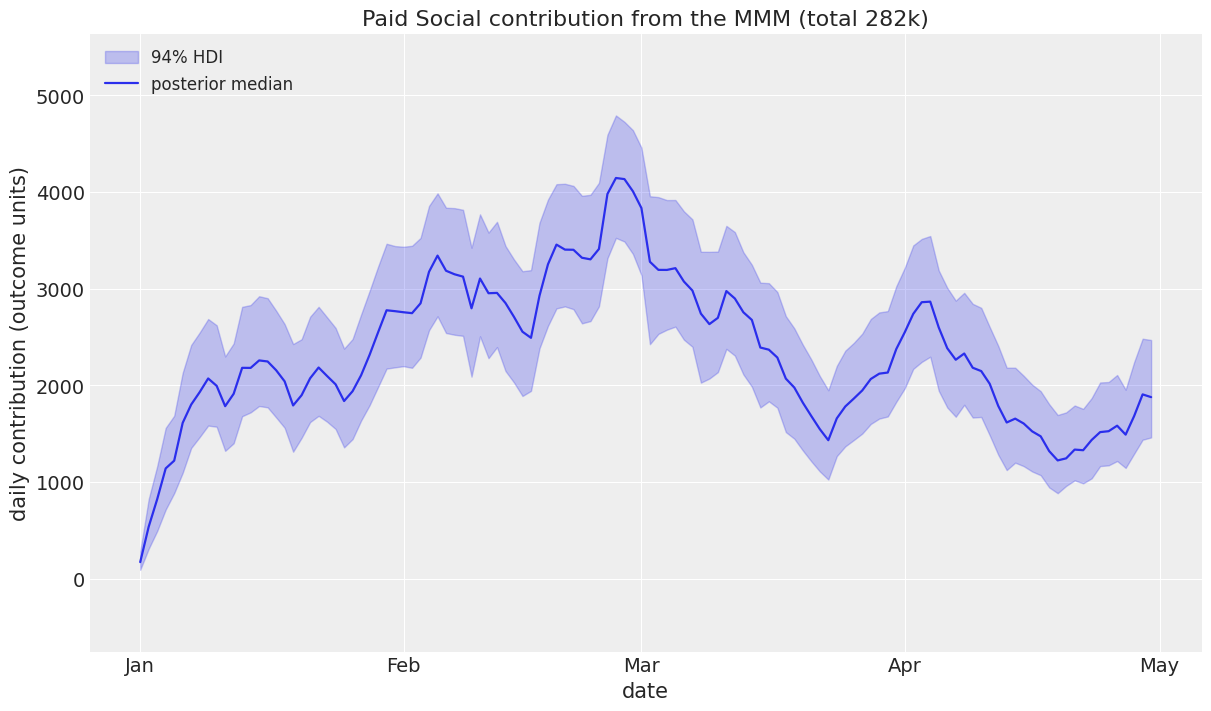

In [10]:
social_daily = data.social.stack(sample=("chain", "draw"))
social_hdi = az.hdi(social_daily, dim="sample")

fig, ax = plt.subplots(figsize=(12, 7), layout="constrained")
ax.fill_between(
    data.mmm["date"],
    social_hdi.sel(ci_bound="lower").to_numpy(),
    social_hdi.sel(ci_bound="upper").to_numpy(),
    color="C0",
    alpha=0.25,
    label=f"{CI_PROB:.0%} HDI",
)
ax.plot(
    data.mmm["date"],
    social_daily.median("sample").to_numpy(),
    color="C0",
    lw=1.6,
    label="posterior median",
)
ax.set(
    title=f"Paid Social contribution from the MMM (total {channel_total / 1e3:,.0f}k)",
    xlabel="date",
    ylabel="daily contribution (outcome units)",
)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.margins(y=0.18)
_ = ax.legend(loc="upper left", fontsize=12)

> **Fig.** What the MMM hands us: Paid Social's daily incremental contribution with its 94% credible interval. That interval is a **highest density interval (HDI)**, the narrowest range that holds 94% of the plausible values, and it is the uncertainty format used for every estimate in this notebook. The area under the curve, about 282k in the MMM's outcome units, is the number we split across campaigns. Everything else in the notebook decides the proportions.

### One more report worth pulling: campaign overlap

The same multi-report trick, asked of campaign *groups*, tells you how much your campaigns compete for the same people. For each pair, pull reach for A alone, for B alone, and for the combined A∪B group. The shared audience is then

$$\text{overlap}(A, B) = \text{Reach}(A) + \text{Reach}(B) - \text{Reach}(A \cup B).$$

Repeat over the pairs (and larger groups) you care about to fill an N by N matrix. Its diagonal is each campaign's own audience size and the off-diagonals are shared users, zero where targeting is disjoint. In this synthetic example the matrix describes **targeting universes**, so a diagonal is a potential audience size rather than the realized cumulative unique reach used below.

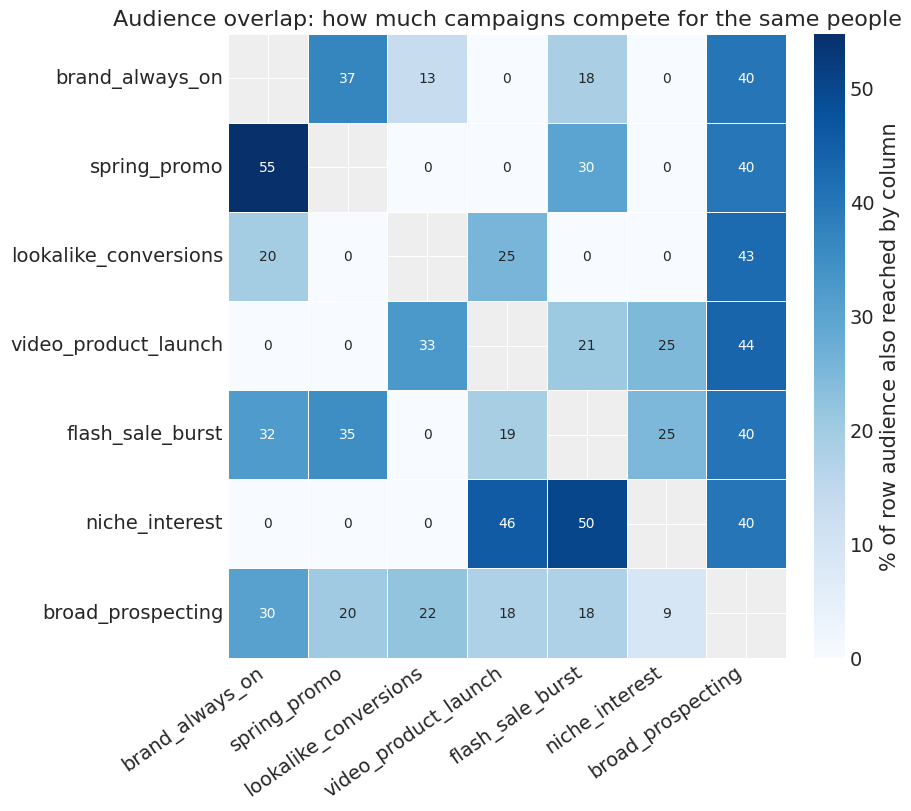

In [11]:
overlap = data.overlap.reindex(index=campaigns, columns=campaigns)
overlap_pct = 100 * overlap.div(pd.Series(np.diag(overlap), index=campaigns), axis=0)

fig, ax = plt.subplots(figsize=(9, 8), layout="constrained")
sns.heatmap(
    overlap_pct,
    mask=np.eye(len(campaigns), dtype=bool),
    annot=True,
    fmt=".0f",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "% of row audience also reached by column"},
    ax=ax,
)
ax.set(
    title="Audience overlap: how much campaigns compete for the same people",
    xlabel="",
    ylabel="",
)
for tick_label in ax.get_xticklabels():
    tick_label.set(rotation=35, horizontalalignment="right")

> **Fig.** Audience overlap from the pairwise reach queries. Read each row as: of that campaign's targeting universe, what share is also targeted by the campaign in each column. Dark cells are contested audiences, and 55% of `spring_promo`'s audience is also targeted by `brand_always_on`. Blank cells on the diagonal are trivially 100%, and pale cells are close to disjoint targeting. This is the competition structure inside your own account.

This notebook only needs the **unique reach** signal from the expanding-window query. The overlap matrix is not used below, but it comes from the same query pattern, it shows how much your campaigns are fighting over the same people, and it is the natural next input if you extend the method, so it is worth building at the same time.

## Step 1: each campaign's own noisy story

To turn the dial we need two numbers per campaign: **how much evidence it carries**, its unique reach, and **its own noisy story**, a rough guess at how much revenue it drove per unit of exposure.

For that own story we do something deliberately crude, exactly the kind of back-of-envelope split a platform dashboard invites. We take the MMM's total social credit, hand it out in proportion to each campaign's **clicks**, and express the result **per reach-day**:

$$y_c=\log\left(\frac{T \cdot \text{clickshare}_c}{R_c}\right),\qquad R_c=\sum_t \text{reach}_{ct}.$$

In words: $y_c$ is the credit per reach-day that a click-share split would imply, on the log scale. It is noisy and non-incremental on purpose: this is the shaky signal we want to discipline, not trust. Two details are worth stating plainly.

- **The denominator is reach-days, not people.** That is the unit the daily allocation later spends, and matching the two is what makes the credit add up. Divide by unique reach instead and full trust in the click signal no longer reproduces the click split, because a campaign's frequency leaks into its share.
- **We work with the log of the rate**, so "twice as effective" is the same size step whether a campaign is weak or strong. All the "log units" quoted below are steps on this scale; a step of 0.40 means a factor of 1.5.

One more thing to be precise about, since the framing is "one number you trust, seven shaky signals". The MMM total $T$ enters $y_c$ as $\log T + \log \text{clickshare}_c - \log R_c$, an identical shift for every campaign, which the collective mean $\mu$ absorbs. So the MMM sets the level of the whole channel, and the *ranking* of the direct estimates comes from click share and exposure alone.

:::{admonition} Clicks are a stand-in, and every click is priced the same
:class: important
Two assumptions ride along with this construction, and neither is innocent.

- **Clicks are a proxy, not the thing itself.** Nothing in the machinery is attached to clicks: conversions, last-touch revenue, or a lift-informed signal slot into the same $y_c$, and if you have a metric you believe tracks incrementality better, use it. What the model disciplines is the *noise* of whichever proxy you feed it; the proxy's *bias* passes straight through ("it cures noise, not bias", as the closing section puts it).
- **A click is priced the same wherever it came from.** The split hands out credit per click regardless of the campaign that earned it, yet the EDA showed median daily CTR differing by a factor of nearly four across campaigns. Two campaigns can deliver identical impressions with very different click counts simply because they were *optimised for different things*, say an awareness push against a click-optimised conversion campaign, and that difference is structural rather than noisy. Evidence turns the dial between a campaign's own story and the collective average; it cannot repair a story that is told in the wrong currency.

The same precision applies to the MMM itself: it enters this construction only as the trusted total $T$, not through its media variables or response curves. One structural piece of the MMM *can* be inherited cheaply: its **adstock**, the carryover that lets today's exposure keep paying off for days afterwards. The adstock extension after the grading section does exactly that.
:::

In [12]:
def naive_click_share(clicks: pd.Series) -> pd.Series:
    """Platform-style split of the channel total, proportional to clicks."""
    return clicks / clicks.sum()


def naive_log_rate(
    channel_total: float, click_share: pd.Series, exposure: pd.Series
) -> pd.Series:
    """Log contribution per unit of exposure implied by the naive click split."""
    return np.log(channel_total * click_share / exposure)


def direct_estimates(data: CampaignData) -> pd.DataFrame:
    """Per-campaign evidence, exposure, and the noisy direct estimate y_c."""
    campaigns = data.campaigns
    totals = campaign_totals(data.metrics, campaigns)
    channel_total = float(data.social.sum("date").mean())
    click_share = naive_click_share(totals["clicks"])
    return pd.DataFrame(
        {
            "unique_reach": final_unique_reach(data.cum_reach, campaigns),
            "reach_days": totals["reach_days"].astype(float),
            "clicks": totals["clicks"],
            "click_share": click_share,
            "naive_rate": channel_total * click_share / totals["reach_days"],
            "y_direct": naive_log_rate(
                channel_total, click_share, totals["reach_days"]
            ),
        }
    )


direct = direct_estimates(data)
y_direct = direct["y_direct"]
unique_reach = direct["unique_reach"]
direct.sort_values("unique_reach", ascending=False).round(4)

,unique_reach,reach_days,clicks,click_share,naive_rate,y_direct
brand_always_on,62386.0,1541137.0,40073,0.3903,0.0714,-2.6399
lookalike_conversions,42733.0,597676.0,16891,0.1645,0.0776,-2.5566
spring_promo,41719.0,438462.0,15985,0.1557,0.1001,-2.3020
flash_sale_burst,34802.0,139620.0,10084,0.0982,0.1982,-1.6183
video_product_launch,33427.0,519340.0,10628,0.1035,0.0562,-2.8794
broad_prospecting,24140.0,32921.0,1294,0.0126,0.1079,-2.2267
niche_interest,17987.0,254475.0,7709,0.0751,0.0831,-2.4872


The picture below is the heart of the problem: each campaign's own noisy story, laid against how much evidence it carries. The bands get **wider the fewer people a campaign reached**, since less evidence means more uncertainty about its rate.

Two campaigns anchor the range. **`flash_sale_burst`** sits highest: it ran 15 days and re-reached each person only four times, so its clicks are divided by very little exposure. **`video_product_launch`** sits lowest, with heavy delivery and the worst CTR in the account. **`niche_interest`** carries the least evidence of all, so its band is the widest on the chart even though its rate is close to the middle.

The dashed line is the **collective mean**: the reach-weighted average of the seven naive log rates, and a plug-in stand-in for the $\mu$ the model will estimate. It is the level each campaign gets pulled toward, in proportion to how little evidence it carries.

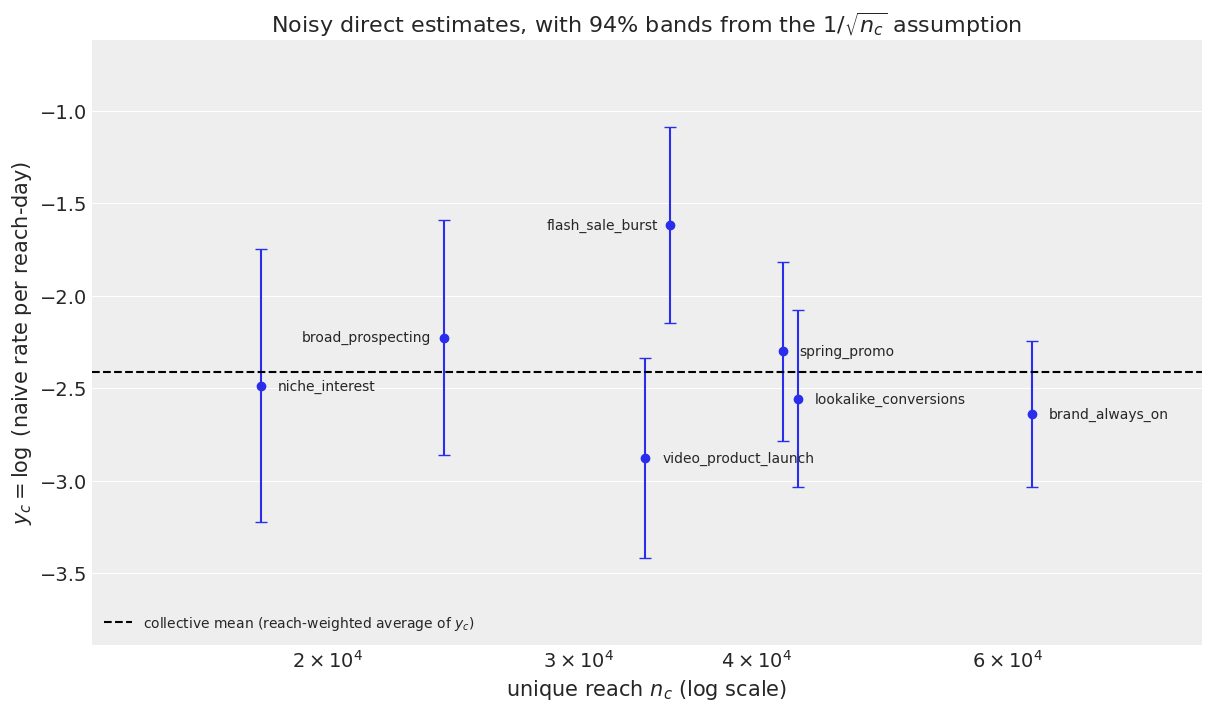

In [13]:
def robust_scale(values: pd.Series) -> float:
    """Outlier-resistant estimate of the dispersion of the direct estimates."""
    return float(1.4826 * np.median(np.abs(values - np.median(values))))


relative_reach = unique_reach / unique_reach.mean()
plug_in_scale = robust_scale(y_direct)
standard_error = np.sqrt(plug_in_scale**2 / relative_reach)
collective_mean = float(np.average(y_direct, weights=unique_reach))
z_score = float(norm.ppf(0.5 + CI_PROB / 2))  # half-width multiplier for a 94% band

ordered = unique_reach.sort_values().index
fig, ax = plt.subplots(figsize=(12, 7), layout="constrained")
ax.errorbar(
    unique_reach[ordered],
    y_direct[ordered],
    yerr=z_score * standard_error[ordered],
    fmt="o",
    capsize=4,
    color="C0",
)
ax.axhline(
    collective_mean,
    ls="--",
    color="black",
    label="collective mean (reach-weighted average of $y_c$)",
)
label_to_the_left = {"broad_prospecting", "flash_sale_burst"}
for campaign in ordered:
    to_the_right = campaign not in label_to_the_left
    ax.annotate(
        campaign,
        (unique_reach[campaign], y_direct[campaign]),
        xytext=(12, -3) if to_the_right else (-9, -3),
        textcoords="offset points",
        ha="left" if to_the_right else "right",
        fontsize=10,
    )
ax.margins(x=0.22, y=0.20)
ax.set(
    xscale="log",
    title=(
        f"Noisy direct estimates, with {CI_PROB:.0%} bands "
        "from the $1/\\sqrt{n_c}$ assumption"
    ),
    xlabel="unique reach $n_c$ (log scale)",
    ylabel="$y_c=\\log$ (naive rate per reach-day)",
)
_ = ax.legend(loc="lower left", fontsize=10)

> **Fig.** Each campaign's noisy own story plotted against its evidence, on a log reach axis. The band shape is the modelling assumption that a campaign's noise falls like $1/\sqrt{n_c}$; its scale here is a crude plug-in, the outlier-resistant spread of the seven direct estimates, and the model replaces it with a fitted $s^2$ in the next step. `niche_interest` carries the least evidence and gets the widest band; `brand_always_on` carries the most and gets the narrowest.

## Step 2: let the data set the dial

Now we let the data set the dial. Instead of decreeing "a campaign is only half-trusted until it reaches 50k people", or handing everyone a flat `Z = 0.5` by gut, we write the blend down as a small model and let it learn, alongside the channel average itself, the **two numbers that set the dial**, estimated from the seven campaigns together:

- **How much campaigns genuinely differ** from one another ($\tau$). If campaigns are basically alike, the group average is very informative and everyone gets pulled toward it hard.
- **How noisy one campaign's own signal is** for a given amount of evidence ($s^2$). The noisier the signal, the more reach it takes to earn trust.

Their ratio is the evidence threshold, $k = s^2/\tau^2$, and each campaign's dial follows automatically: $Z_c = n_c/(n_c+k)$. Because we fit this as a Bayesian model we do not get a single $Z$ per campaign, we get a distribution. Even the trust carries an error bar.

Statisticians call this **partial pooling**: every campaign borrows strength from the others, in proportion to how little evidence it has of its own, and the resulting pull toward the group average is called **shrinkage**. Both words appear in the figures below and mean exactly this.

:::{admonition} You are already setting Z, you just do not call it that
:class: note
Every day-to-day call about campaign performance is a Z in disguise, set by gut.

- **Reading the dashboard at face value is `Z = 1`.** "This campaign shows 8x ROAS, that one 2x, move the budget" trusts each number fully, no matter how few people it reached. It is why small campaigns swing between hero and flop week to week.
- **Splitting the credit by delivery is `Z = 0`.** You have thrown away each campaign's own signal and handed out credit in proportion to reach alone. Splitting by spend, or evenly, is `Z = 0` in spirit: the average rules and the campaign's own story is ignored.
- **"Wait for enough conversions before you trust the CPA" is choosing `k`**, the evidence threshold where belief kicks in. Meta and Google do exactly this with their campaign *learning phase*.
- **"That 12x looks too good, tiny audience, call it maybe 4x" is a blend.** That is credibility done in your head, at an unspoken Z somewhere between 0 and 1.

You cannot avoid picking a Z. The only question is whether it is an arbitrary gut call that shifts by analyst and by mood, or **one value estimated from how your campaigns actually behave**, with its uncertainty attached. That is all the model below does.
:::

The model is short, and it is the entire method. Everything before it was preparing its two inputs, and everything after it is presentation.

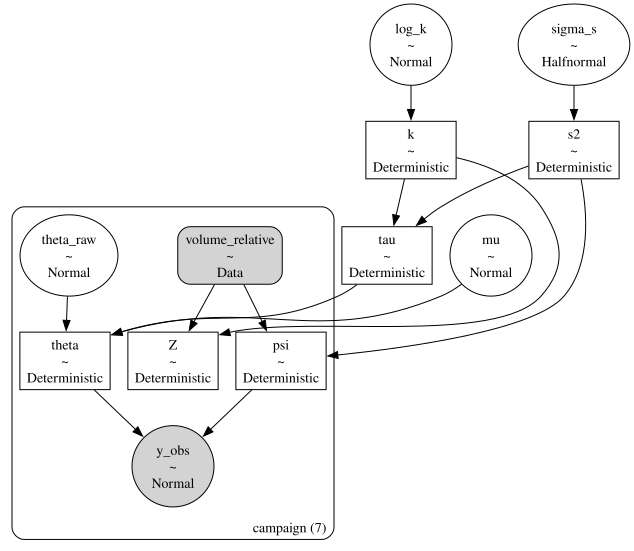

In [14]:
def build_credibility_model(
    y_direct: pd.Series,
    volume: pd.Series,
    *,
    sigma_s_scale: float = 0.5,
    log_k_sd: float = 0.75,
) -> pm.Model:
    """Buhlmann credibility model in which volume sets each campaign's trust dial."""
    campaigns = list(y_direct.index)
    volume_relative = (volume / volume.mean()).reindex(campaigns).to_numpy()
    with pm.Model(coords={"campaign": campaigns}) as model:
        volume_data = pm.Data("volume_relative", volume_relative, dims="campaign")
        mu = pm.Normal("mu", mu=float(y_direct.mean()), sigma=1.0)
        log_k = pm.Normal("log_k", 0.0, log_k_sd)
        k = pm.Deterministic("k", pm.math.exp(log_k))
        sigma_s = pm.HalfNormal("sigma_s", sigma_s_scale)
        s2 = pm.Deterministic("s2", sigma_s**2)
        tau = pm.Deterministic("tau", pm.math.sqrt(s2 / k))
        psi = pm.Deterministic("psi", s2 / volume_data, dims="campaign")
        pm.Deterministic("Z", volume_data / (volume_data + k), dims="campaign")
        theta_raw = pm.Normal("theta_raw", 0.0, 1.0, dims="campaign")
        theta = pm.Deterministic("theta", mu + tau * theta_raw, dims="campaign")
        pm.Normal(
            "y_obs",
            mu=theta,
            sigma=pm.math.sqrt(psi),
            observed=y_direct.to_numpy(),
            dims="campaign",
        )
    return model


credibility_model = build_credibility_model(y_direct, unique_reach)
pm.model_to_graphviz(credibility_model)

> **Fig.** The model graph. The plate holds the seven campaigns, `volume_relative` is the data node carrying each campaign's unique reach divided by the average unique reach, and everything inside the plate is per-campaign. Only `mu`, `log_k` and `sigma_s` are global.

Reading it line by line: `mu` is the channel-average effectiveness every campaign is judged against, `sigma_s` sets how noisy one campaign's own signal is per unit of evidence, `psi` is that noise for a given campaign, `Z` is the trust dial that falls out, and `theta` is each campaign's trust-adjusted effectiveness, the blend of its own story and the group average.

The model samples $\log k$ directly, so the prior on the evidence threshold is a statement a media analyst can argue with: "a campaign of average size starts out about half believed, give or take". The prior predictive check below shows what that implies before any data are used.

:::{dropdown} For the statistically minded: parametrisation, priors and a weak identification
We sample $\log k$ and derive $\tau=\sqrt{s^2/k}$, rather than sampling $\tau$ and $s^2$ separately, for two reasons. First, $k$ is the actuarial quantity of interest, the amount of reach at which a campaign earns half its own trust, so putting a prior on it is meaningful. Second, the $(\tau, s^2)$ pair is only weakly identified from seven campaigns: sampling those two directly produced divergences at `target_accept=0.95` while this version produces none.

Marginalising out $\theta_c$, the model says

$$y_c \sim \text{Normal}\left(\mu,\; \tau^2+\psi_c\right), \qquad \tau^2+\psi_c = s^2\left(\frac{1}{k}+\frac{1}{n^{\text{rel}}_c}\right),$$

so $s^2$ and $k$ enter only through that combination. What separates them is the spread of relative reach across campaigns, which here runs from 0.49 to 1.70. With seven campaigns and a 3.5-fold spread, that separation is weak, and the posterior for $k$ stays wide. This is the honest reason the priors deserve a check rather than a shrug, and why the robustness checks sweep them.

Could more data sharpen it? The tempting route is time series: cut each flight into weeks and let dozens of weekly direct estimates $y_{c,w}$ inform $s^2$ and $k$ instead of seven flight totals. We deliberately do not. The extra rows are far from independent evidence: unique reach is cumulative, so consecutive weekly evidence increments are strongly autocorrelated; the weekly click shares are still one composition per week; and within a campaign, whatever moves its share in one week (a creative, an audience, a promotion) tends to move it in the next. Modelling that dependence honestly costs more structure than seven campaigns can support, so this notebook keeps the flight-level model and spends its scepticism on the robustness checks instead.

On the `sigma_s` prior: a `HalfNormal(0.5)` implies simulated flights whose spread across campaigns has a median of 0.41, against the observed 0.40, with an interquartile range of 0.20 to 0.73. A tighter `HalfNormal(0.4)` would imply a median spread of 0.34 and a wider `HalfNormal(0.7)` 0.59, so the chosen prior covers the data comfortably from both sides without insisting on the observed value; the alternatives bracket it, and the robustness checks show none of them changes the conclusions.

One more disclosure: $\mu$'s prior is centered on the mean of the observed $y_c$. With a prior standard deviation of 1.0 against a data spread of 0.40 the effect is mild, but it is the data informing a prior, not prior information.
:::

In [15]:
with credibility_model:
    prior = pm.sample_prior_predictive(draws=1_000, random_seed=rng)

prior_z = prior.prior["Z"].stack(sample=("chain", "draw"))
prior_k_people = (
    prior.prior["k"].stack(sample=("chain", "draw")).to_numpy() * unique_reach.mean()
)
prior_spread = (
    prior.prior_predictive["y_obs"].stack(sample=("chain", "draw")).std("campaign")
)


def prior_spread_median(sigma_s_scale: float) -> float:
    """Median spread of the simulated flights implied by one `sigma_s` prior scale."""
    with build_credibility_model(y_direct, unique_reach, sigma_s_scale=sigma_s_scale):
        drawn = pm.sample_prior_predictive(draws=1_000, random_seed=seed)
    simulated = drawn.prior_predictive["y_obs"].stack(sample=("chain", "draw"))
    return float(simulated.std("campaign").median())


prior_spread_by_scale = pd.Series(
    {
        scale: prior_spread_median(scale)
        if scale != 0.5
        else float(prior_spread.median())
        for scale in (0.4, 0.5, 0.7)
    },
    name="prior median spread of y_c across campaigns",
).rename_axis("sigma_s prior scale")
print(f"observed spread of y_c across campaigns: {y_direct.std(ddof=1):.2f}")
display(prior_spread_by_scale.round(2))

prior_z_table = pd.DataFrame(
    {
        "unique_reach": unique_reach,
        "prior_median_Z": prior_z.median("sample").to_pandas(),
        "prior_Z_3%": prior_z.quantile(0.03, "sample").to_pandas(),
        "prior_Z_97%": prior_z.quantile(0.97, "sample").to_pandas(),
    }
).sort_values("unique_reach", ascending=False)
prior_z_table.round(3)

Sampling: [log_k, mu, sigma_s, theta_raw, y_obs]


Sampling: [log_k, mu, sigma_s, theta_raw, y_obs]


Sampling: [log_k, mu, sigma_s, theta_raw, y_obs]


observed spread of y_c across campaigns: 0.40


sigma_s prior scale
0.4    0.34
0.5    0.41
0.7    0.59
Name: prior median spread of y_c across campaigns, dtype: float64

,unique_reach,prior_median_Z,prior_Z_3%,prior_Z_97%
brand_always_on,62386.0,0.634,0.295,0.874
lookalike_conversions,42733.0,0.542,0.223,0.826
spring_promo,41719.0,0.537,0.219,0.823
flash_sale_burst,34802.0,0.491,0.189,0.795
video_product_launch,33427.0,0.481,0.183,0.788
broad_prospecting,24140.0,0.401,0.139,0.728
niche_interest,17987.0,0.333,0.108,0.667


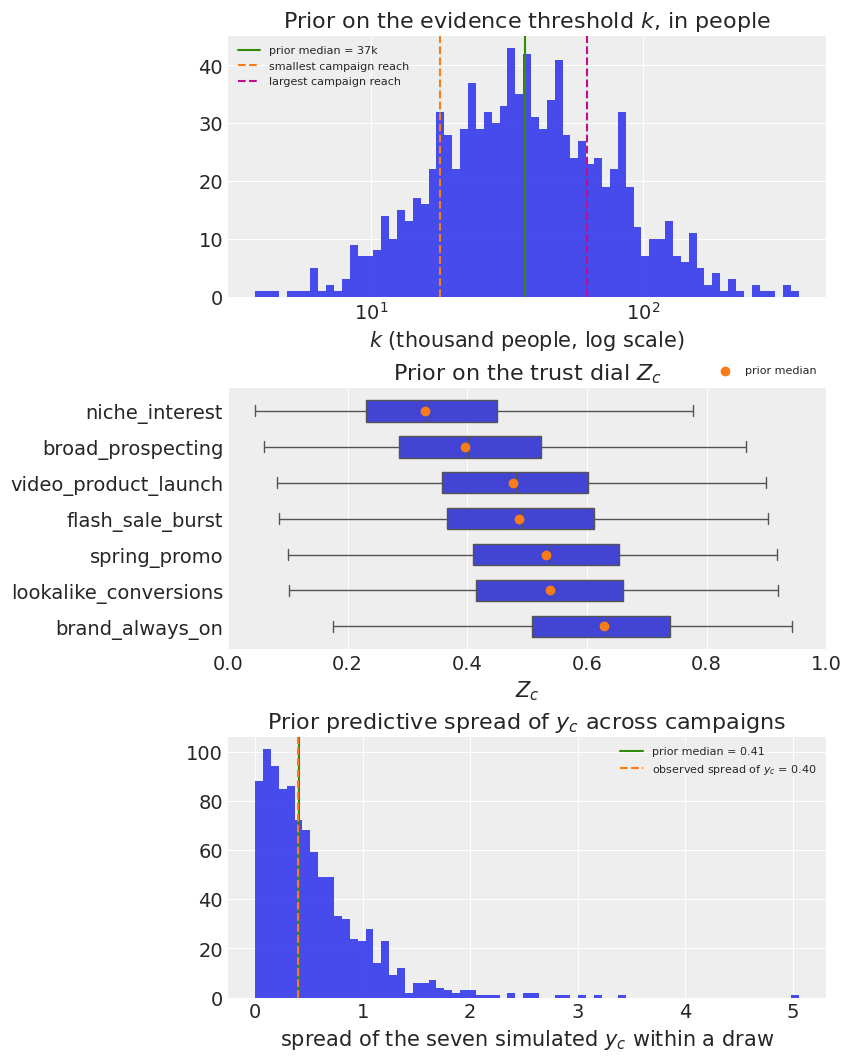

In [16]:
fig, (ax_k, ax_z, ax_y) = plt.subplots(
    nrows=3, figsize=(8.4, 10.5), layout="constrained"
)

ax_k.hist(
    prior_k_people / 1e3,
    bins=np.geomspace(prior_k_people.min() / 1e3, prior_k_people.max() / 1e3, 70),
    color="C0",
    alpha=0.85,
)
# the prior median of k is exactly 1 in relative units, so it is the average reach
ax_k.axvline(
    unique_reach.mean() / 1e3,
    color="C2",
    ls="-",
    label=f"prior median = {unique_reach.mean() / 1e3:.0f}k",
)
ax_k.axvline(
    unique_reach.min() / 1e3, color="C1", ls="--", label="smallest campaign reach"
)
ax_k.axvline(
    unique_reach.max() / 1e3, color="C3", ls="--", label="largest campaign reach"
)
ax_k.set(
    xscale="log",
    xlabel="$k$ (thousand people, log scale)",
    title="Prior on the evidence threshold $k$, in people",
)
ax_k.legend(loc="upper left", fontsize=8)

z_order = unique_reach.sort_values().index.tolist()
prior_z_draws = pd.DataFrame(
    {campaign: prior_z.sel(campaign=campaign).to_numpy() for campaign in z_order}
).melt(var_name="campaign", value_name="Z")
sns.boxplot(
    data=prior_z_draws,
    x="Z",
    y="campaign",
    order=z_order,
    orient="h",
    width=0.6,
    showfliers=False,
    color="C0",
    ax=ax_z,
)
ax_z.scatter(
    [relative_reach[campaign] / (relative_reach[campaign] + 1) for campaign in z_order],
    np.arange(len(z_order)),
    color="C1",
    zorder=3,
    label="prior median",
)
ax_z.set(
    xlim=(0, 1),
    xlabel="$Z_c$",
    ylabel="",
    title="Prior on the trust dial $Z_c$",
)
# above the axes, so the legend cannot sit on top of a whisker
ax_z.legend(loc="lower right", bbox_to_anchor=(1.0, 1.01), fontsize=8)

# bins spanning the full sampled range, so no part of the prior is clipped away
ax_y.hist(
    prior_spread.to_numpy(),
    bins=np.linspace(0, float(prior_spread.max()), 70),
    color="C0",
    alpha=0.85,
)
ax_y.axvline(
    float(prior_spread.median()),
    color="C2",
    ls="-",
    label=f"prior median = {float(prior_spread.median()):.2f}",
)
ax_y.axvline(
    float(y_direct.std(ddof=1)),
    color="C1",
    ls="--",
    label=f"observed spread of $y_c$ = {y_direct.std(ddof=1):.2f}",
)
ax_y.set(
    xlabel="spread of the seven simulated $y_c$ within a draw",
    title="Prior predictive spread of $y_c$ across campaigns",
)
_ = ax_y.legend(loc="upper right", fontsize=8)

> **Fig.** Prior predictive checks, top to bottom. The top panel puts the evidence threshold $k$ on a scale a media analyst can argue with. Its prior median is about 37k people, which is the average campaign's unique reach in a field spanning 18k to 62k. In plain language: **before seeing any data, a campaign of average size starts out about half believed**, and the prior leaves plenty of room on both sides.
>
> The middle panel shows what that implies for each campaign's dial. The prior on $Z_c$ deliberately does **not** span 0 to 1 for every campaign: because the prior median of $k$ equals the average reach, the prior median of $Z_c$ is $n^{\text{rel}}_c/(n^{\text{rel}}_c+1)$, marked by the orange dots, which already encodes "bigger campaigns start out more trusted". `brand_always_on` starts at a median of 0.63, `niche_interest` at 0.33, each with a wide range around it (see the table above). That is wide enough for the data to move the dial and narrow enough to rule out the two extremes a priori.
>
> The bottom panel is the check on the noise prior: the simulated flights spread across campaigns by about as much as the real ones do (prior median 0.41 against an observed 0.40), with a wide range around it, so the prior covers the data without insisting on it.

Now we fit the model.

In [17]:
def fit_credibility(
    model: pm.Model, *, sample_seed: int = seed, progressbar: bool = True
) -> xr.DataTree:
    """Sample the credibility model with the settings used throughout the notebook."""
    with model:
        return pm.sample(
            draws=1_000,
            tune=1_000,
            chains=4,
            cores=4,
            target_accept=0.95,
            random_seed=sample_seed,
            progressbar=progressbar,
        )


idata = fit_credibility(credibility_model)

posterior = idata.posterior
divergences = int(idata.sample_stats["diverging"].sum())
max_rhat = float(az.summary(idata, var_names=["mu", "log_k", "sigma_s"])["r_hat"].max())
k_people = float(posterior["k"].median()) * unique_reach.mean()
trust = posterior["Z"].mean(("chain", "draw")).to_pandas().reindex(campaigns)

print(
    f"{divergences} divergences, max R-hat {max_rhat:.3f}: the sampler is healthy.\n"
    f"Posterior median evidence threshold k = {k_people:,.0f} people, so the fitted "
    f"trust dial runs from {trust.min():.2f} ({trust.idxmin()}) to {trust.max():.2f} "
    f"({trust.idxmax()})."
)
az.summary(idata, var_names=["mu", "k", "sigma_s", "tau"]).round(3)

NUTS[nutpie]: [mu, log_k, sigma_s, theta_raw]


Output()

0 divergences, max R-hat 1.000: the sampler is healthy.
Posterior median evidence threshold k = 37,061 people, so the fitted trust dial runs from 0.34 (niche_interest) to 0.61 (brand_always_on).


,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu,-2.401,0.194,-2.8,-2,1785,1687,1.00,0.0049,0.0048
k,1.32,1.1,0.24,4.1,1719,1722,1.00,0.023,0.056
sigma_s,0.33,0.118,0.16,0.6,1513,1466,1.00,0.0029,0.0028
tau,0.332,0.133,0.16,0.64,3141,2350,1.00,0.0026,0.0035


Two things to read off. First, the sampler diagnostics: no divergences and $\hat R$ of 1.00 mean the four chains agree, so the numbers below can be trusted as a faithful picture of the posterior. Second, the threshold: it is reported as the posterior **median** rather than the mean, because $k$ is sampled on the log scale and its posterior is right-skewed. Note what the fitted range of $Z$ does and does not say: even the best-measured campaign in this account is only slightly more than half believed, and the smallest sits near a third.

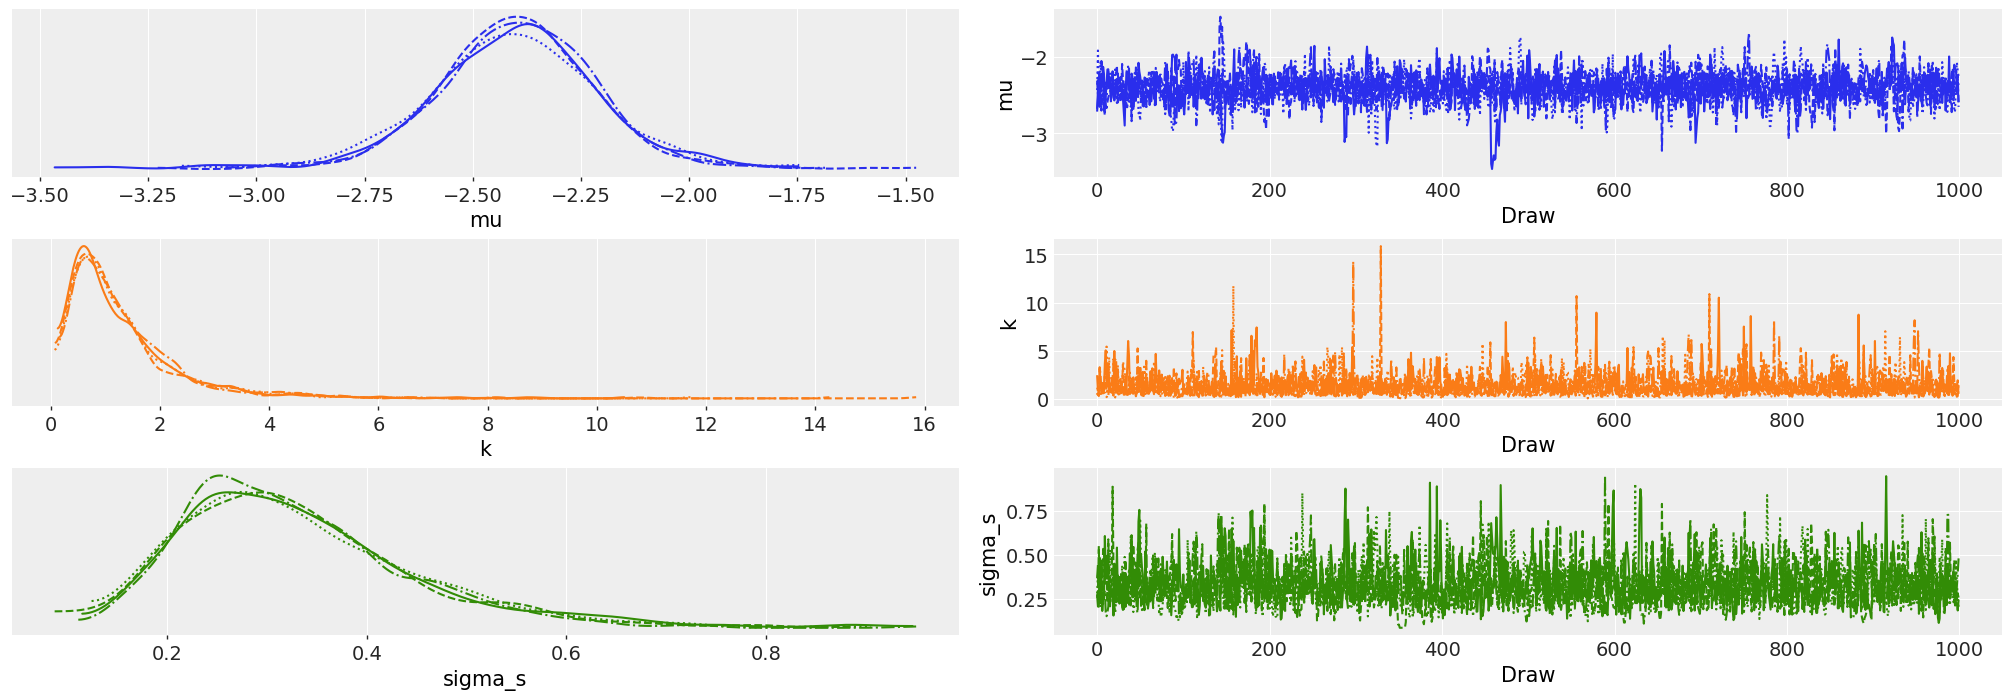

In [18]:
_ = azp.plot_trace_dist(idata, var_names=["mu", "k", "sigma_s"])

> **Fig.** Marginal posteriors and traces for the three sampled quantities. The chains mix, and `k` is visibly skewed and wide, which is the weak identification described in the dropdown above showing up in the output rather than hiding in it.

### The fitted dial

This is the picture from the introduction, now with the data in it. The curve is the fitted trust dial, the band around it is the uncertainty in the threshold $k$, and each dot is a real campaign placed at its unique reach, with a whisker for the uncertainty in its own $Z_c$.

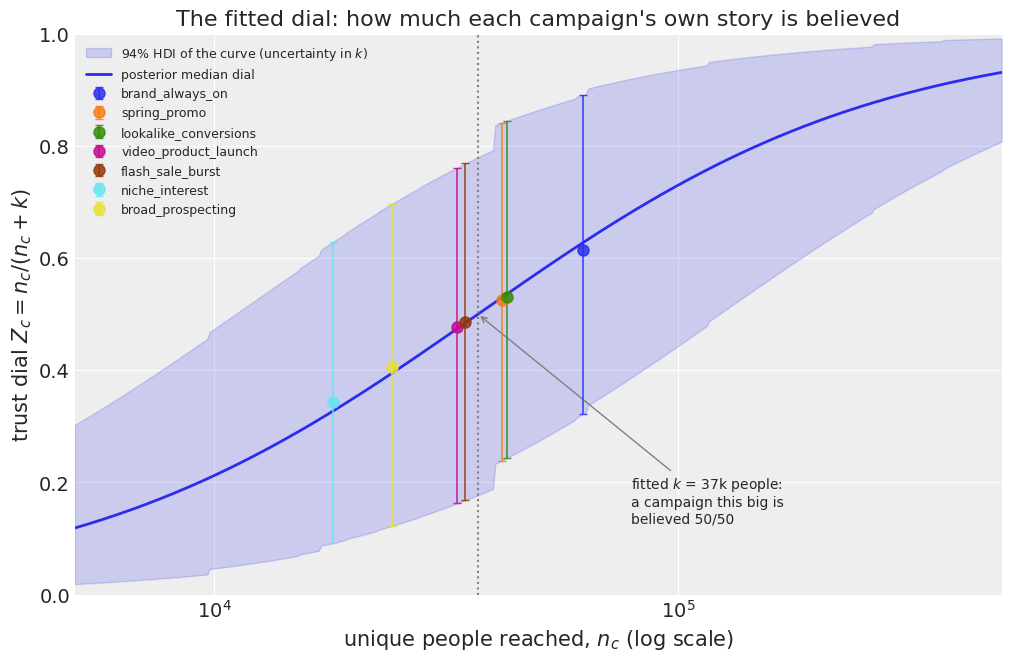

In [19]:
k_draws_people = posterior["k"].to_numpy().ravel() * unique_reach.mean()
z_curves = xr.DataArray(
    people_grid[None, :] / (people_grid[None, :] + k_draws_people[:, None]),
    dims=("sample", "n"),
)
z_curve_hdi = az.hdi(z_curves, dim="sample")
z_posterior = posterior["Z"].stack(sample=("chain", "draw"))
z_bounds = az.hdi(z_posterior, dim="sample")

fig, ax = plt.subplots(figsize=(10, 6.5), layout="constrained")
ax.fill_between(
    people_grid,
    z_curve_hdi.sel(ci_bound="lower").to_numpy(),
    z_curve_hdi.sel(ci_bound="upper").to_numpy(),
    color="C0",
    alpha=0.18,
    label=f"{CI_PROB:.0%} HDI of the curve (uncertainty in $k$)",
)
ax.plot(
    people_grid,
    z_curves.median("sample").to_numpy(),
    color="C0",
    lw=2,
    label="posterior median dial",
)
for campaign in campaigns:
    ax.errorbar(
        unique_reach[campaign],
        trust[campaign],
        yerr=[
            [
                trust[campaign]
                - float(z_bounds.sel(campaign=campaign, ci_bound="lower"))
            ],
            [
                float(z_bounds.sel(campaign=campaign, ci_bound="upper"))
                - trust[campaign]
            ],
        ],
        fmt="o",
        ms=8,
        capsize=3,
        elinewidth=1.2,
        alpha=0.85,
        color=colors[campaign],
        label=campaign,
        zorder=4,
    )
ax.axvline(k_people, ls=":", color="gray")
ax.annotate(
    f"fitted $k$ = {k_people / 1e3:.0f}k people:\na campaign this big is\nbelieved 50/50",
    (k_people, 0.5),
    xytext=(110, -150),
    textcoords="offset points",
    ha="left",
    fontsize=10,
    arrowprops={"arrowstyle": "->", "color": "gray"},
)
ax.set(
    xscale="log",
    xlim=(5e3, 5e5),
    ylim=(0, 1),
    xlabel="unique people reached, $n_c$ (log scale)",
    ylabel="trust dial $Z_c = n_c / (n_c + k)$",
    title="The fitted dial: how much each campaign's own story is believed",
)
_ = ax.legend(loc="upper left", fontsize=9)

> **Fig.** The fitted trust dial with the seven campaigns on it. Reading it left to right: `niche_interest` at 18k people is believed about a third, `brand_always_on` at 62k about 61%, and the whole account sits on the steep part of the curve, so extra reach still buys trust quickly. The band is wide, because seven campaigns pin down the threshold $k$ only loosely; that is honest, and the robustness checks measure how much it matters. Compared with the introduction's picture, the data have chosen the middle curve: a threshold of about 37k people.

### Watch the rates move toward the collective centre

This is the payoff picture. Each orange dot is a campaign's **naive** self-report and each arrow shows where the model moved it after weighing the evidence. The number under each campaign is its trust dial **Z**, and campaigns are sorted by unique reach with the smallest on the left.

The size of each move is not arbitrary. Credibility says

$$\theta_c - y_c = (1-Z_c)\,(\mu - y_c),$$

so a campaign moves by its distance from the collective mean, discounted by how much trust it has earned. That predicts the two things you see. `flash_sale_burst` starts furthest above the collective rate, because its clicks are divided by only four reach-days per person, and takes the largest step down. `video_product_launch` starts furthest below, with the account's worst CTR against heavy delivery, and takes the largest step up. `niche_interest` has the lowest trust dial of all but barely moves, because it started close to the middle.

That is the discipline this method buys: a loud dashboard number is not a licence to scale a campaign, and a quiet one is not proof of failure. The adjustment is earned by evidence, and it protects a big steady campaign from being punished for one unlucky week just as much as it reins in a small loud one.

In [20]:
collective_rate = float(np.exp(posterior["mu"].mean()))
theta_mean = posterior["theta"].mean(("chain", "draw")).to_pandas().reindex(campaigns)
blend = trust * y_direct + (1 - trust) * float(posterior["mu"].mean())
blend_gap = float(np.abs(theta_mean - blend).max())

shrinkage = pd.DataFrame(
    {
        "unique_reach": unique_reach.astype(int),
        "reach_days": direct["reach_days"].astype(int),
        "Z": trust,
        "naive_rate": direct["naive_rate"],
        "credible_rate": np.exp(theta_mean),
        "collective_rate": collective_rate,
    }
).sort_values("unique_reach")

print(
    f"Collective rate exp(mu) = {collective_rate:.4f} per reach-day. The posterior mean "
    f"theta reproduces the blend Z * y + (1 - Z) * mu to within {blend_gap:.3f} log units."
)
shrinkage.round(4)

Collective rate exp(mu) = 0.0906 per reach-day. The posterior mean theta reproduces the blend Z * y + (1 - Z) * mu to within 0.004 log units.


,unique_reach,reach_days,Z,naive_rate,credible_rate,collective_rate
niche_interest,17987,254475,0.3434,0.0831,0.0882,0.0906
broad_prospecting,24140,32921,0.4051,0.1079,0.0969,0.0906
video_product_launch,33427,519340,0.4766,0.0562,0.0719,0.0906
flash_sale_burst,34802,139620,0.4855,0.1982,0.1323,0.0906
spring_promo,41719,438462,0.5259,0.1001,0.0958,0.0906
lookalike_conversions,42733,597676,0.5312,0.0776,0.0834,0.0906
brand_always_on,62386,1541137,0.6138,0.0714,0.0784,0.0906


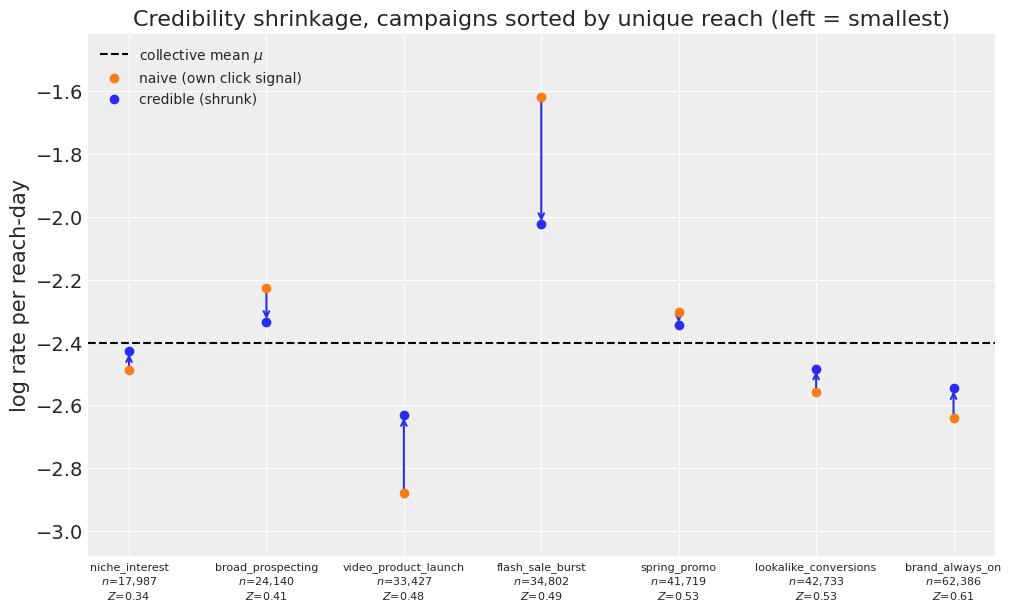

In [21]:
positions = np.arange(len(shrinkage))
fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")
ax.axhline(
    np.log(collective_rate), color="black", ls="--", label=r"collective mean $\mu$"
)
for position, (_, row) in enumerate(shrinkage.iterrows()):
    ax.annotate(
        "",
        xy=(position, np.log(row["credible_rate"])),
        xytext=(position, np.log(row["naive_rate"])),
        arrowprops={"arrowstyle": "->", "color": "C0", "lw": 1.5},
    )
ax.scatter(
    positions,
    np.log(shrinkage["naive_rate"]),
    color="C1",
    zorder=3,
    label="naive (own click signal)",
)
ax.scatter(
    positions,
    np.log(shrinkage["credible_rate"]),
    color="C0",
    zorder=3,
    label="credible (shrunk)",
)
ax.set(
    xticks=positions,
    xticklabels=[
        f"{campaign}\n$n$={reach:,}\n$Z$={z:.2f}"
        for campaign, reach, z in zip(
            shrinkage.index,
            shrinkage["unique_reach"],
            shrinkage["Z"],
            strict=True,
        )
    ],
    ylabel="log rate per reach-day",
    title="Credibility shrinkage, campaigns sorted by unique reach (left = smallest)",
)
ax.tick_params(axis="x", labelsize=8)
ax.margins(y=0.16)
_ = ax.legend(loc="upper left", fontsize=10)

> **Fig.** Naive self-report (orange) to trust-adjusted estimate (blue), as log rates per reach-day. Each campaign moves toward the collective mean by a fraction $1-Z_c$ of its distance from it, so the largest steps belong to the campaigns that combine a low trust dial with an extreme starting point. The collective rate is 0.0906 per reach-day, and the table above confirms that the posterior means really are the blend $Z_c y_c + (1-Z_c)\mu$, to within 0.004 log units.

## Step 3: hand the credit back, day by day

The trust-adjusted rates say how much each campaign earns **per reach-day**. To turn that into daily credit we score each campaign on each day by its credible rate times its reach that day, and hand out the MMM's channel curve in those proportions. Concretely: if campaign A is twice as effective per reach-day, but campaign B delivered three times as many reach-days on Tuesday, B gets 1.5 times A's share of Tuesday's credit.

The weights add to one every single day, so the campaign pieces **always sum back exactly to the MMM's channel total**. We are not inventing a second model of the world, we are dividing the one number we trust.

Both sources of uncertainty travel through. The MMM posterior holds 4 chains of 100 draws, so we pair all 400 of them with 400 draws from the credibility posterior and carry the pairs through the allocation.

Because the rate is per reach-day, the two ends of the dial are quantities you already recognise:

- at $Z=0$ every campaign is judged by the collective rate alone, so the credit follows **delivery**, giving the daily-reach split;
- at $Z=1$ every campaign is believed completely, and the reach-days in the numerator cancel the reach-days in the denominator, giving back the **click split**.

So the dial genuinely interpolates between the two splits an analyst would reach for first, and the fitted answer sits in between. The common-dial sweep in the next section makes this visible.

One structural caveat: the weights are undefined on a day when the whole channel delivered nothing, since the scores would all be zero. Every date in this window has delivery somewhere. On a dark day you would need a convention, and the honest one is that a day with no delivery earns no credit.

In [22]:
def daily_reach(metrics: pd.DataFrame, campaigns: list[str]) -> xr.DataArray:
    """Daily duplicated reach per campaign, the exposure the credit is spent over."""
    wide = metrics.pivot(index="date", columns="campaign", values="reach").reindex(
        columns=campaigns
    )
    return xr.DataArray(
        wide.to_numpy(dtype=float),
        dims=("date", "campaign"),
        coords={"date": wide.index, "campaign": campaigns},
    )


def paired_draws(
    social: xr.DataArray,
    theta: xr.DataArray,
    *,
    pair_seed: int = seed,
) -> tuple[xr.DataArray, xr.DataArray]:
    """Pair MMM and credibility draws so both uncertainties propagate."""
    flat_social = social.stack(sample=("chain", "draw")).transpose("sample", "date")
    flat_theta = theta.stack(sample=("chain", "draw")).transpose("sample", "campaign")
    n_draws = flat_social.sizes["sample"]
    available = flat_theta.sizes["sample"]
    picked = np.random.default_rng(pair_seed).choice(
        available, size=n_draws, replace=available < n_draws
    )
    sample = np.arange(n_draws)
    return (
        flat_social.drop_vars(["sample", "chain", "draw"]).assign_coords(sample=sample),
        flat_theta.isel(sample=picked)
        .drop_vars(["sample", "chain", "draw"])
        .assign_coords(sample=sample),
    )


def allocation_weights(theta_draws: xr.DataArray, reach: xr.DataArray) -> xr.DataArray:
    """Daily weights proportional to the credible rate times daily reach."""
    score = np.exp(theta_draws - theta_draws.max("campaign")) * reach
    return score / score.sum("campaign")


def allocate(social_draws: xr.DataArray, weights: xr.DataArray) -> xr.DataArray:
    """Spend each MMM channel draw over campaigns using the daily weights."""
    return (weights * social_draws).rename("campaign_contribution")


def flight_share(contribution: xr.DataArray) -> xr.DataArray:
    """Flight-total share of the channel per campaign, one value per draw."""
    flight = contribution.sum("date")
    return flight / flight.sum("campaign")


reach = daily_reach(data.metrics, campaigns)
social_draws, theta_draws = paired_draws(data.social, posterior["theta"])
contribution = allocate(social_draws, allocation_weights(theta_draws, reach))
share = flight_share(contribution).transpose("sample", "campaign")

delivery_split = (reach.sum("date").to_pandas() / float(reach.sum())).reindex(campaigns)
click_split = direct["click_share"]

reconciliation = float(np.abs(contribution.sum("campaign") - social_draws).max())
print(
    f"Largest per-day gap between the campaign pieces and the MMM draw, across all "
    f"{share.sizes['sample']} paired draws: {reconciliation:.1e}. The split is exact."
)

Largest per-day gap between the campaign pieces and the MMM draw, across all 400 paired draws: 1.8e-12. The split is exact.


Here is the split itself: every day's MMM credit divided among the campaigns, stacking back to the channel curve.

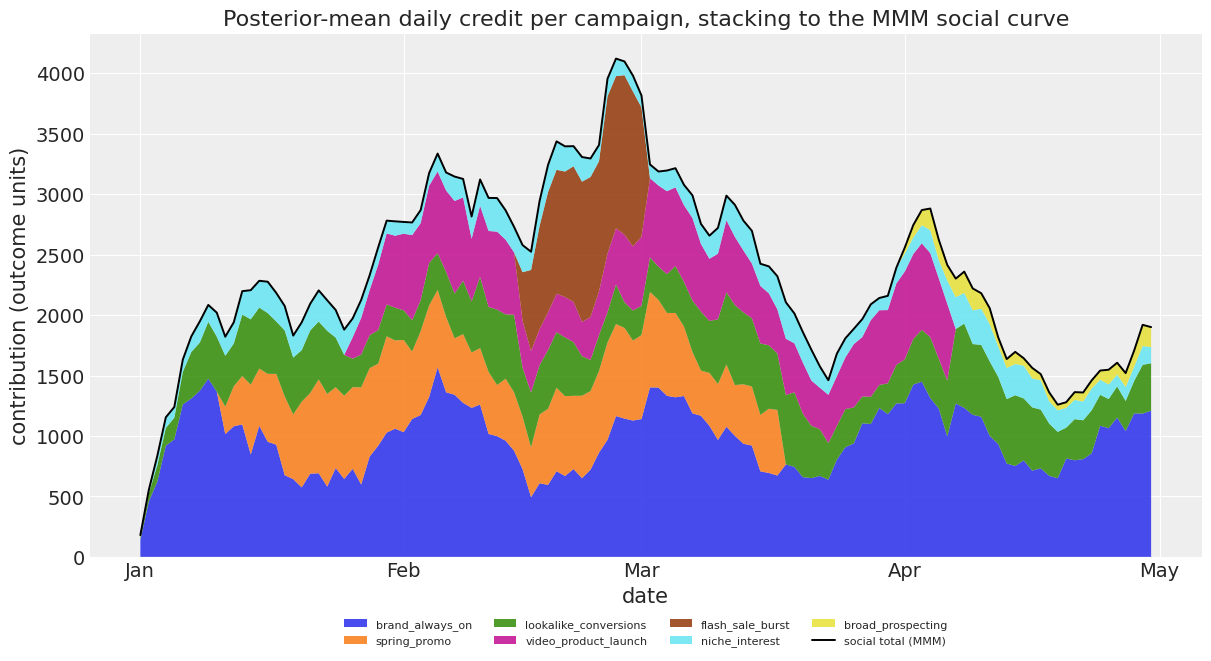

In [23]:
daily_mean = contribution.mean("sample")

fig, ax = plt.subplots(figsize=(12, 6.5), layout="constrained")
ax.stackplot(
    reach.date,
    [daily_mean.sel(campaign=campaign).to_numpy() for campaign in campaigns],
    labels=campaigns,
    colors=[colors[campaign] for campaign in campaigns],
    alpha=0.85,
)
ax.plot(
    reach.date,
    social_draws.mean("sample").to_numpy(),
    color="black",
    lw=1.4,
    label="social total (MMM)",
)
ax.set(
    title="Posterior-mean daily credit per campaign, stacking to the MMM social curve",
    xlabel="date",
    ylabel="contribution (outcome units)",
)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
_ = ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=4, fontsize=8)

> **Fig.** Daily credit per campaign, stacking to the MMM social curve by construction. Within a campaign the day-to-day shape is inherited from its daily reach, which is why the `broad_prospecting` slice appears from nothing in April and the `flash_sale_burst` slice is a 15-day wedge in February. The grading section asks whether that inherited shape is right, and the adstock extension improves it.

And here is what you bring to the meeting: each campaign's credited contribution over the window, with its uncertainty, its share of the channel, and the trust dial that produced it.

In [24]:
flight_total = contribution.sum("date")
flight_bounds = az.hdi(flight_total, dim="sample")
meeting_table = (
    pd.DataFrame(
        {
            "credited_contribution": flight_total.mean("sample").to_pandas(),
            "hdi_low": flight_bounds.sel(ci_bound="lower").to_pandas(),
            "hdi_high": flight_bounds.sel(ci_bound="upper").to_pandas(),
            "share_%": 100 * share.mean("sample").to_pandas(),
            "Z": trust,
        }
    )
    .reindex(campaigns)
    .sort_values("credited_contribution", ascending=False)
)
meeting_table.round(
    {"credited_contribution": 0, "hdi_low": 0, "hdi_high": 0, "share_%": 1, "Z": 2}
)

,credited_contribution,hdi_low,hdi_high,share_%,Z
campaign,,,,,
brand_always_on,116765.0,79341.0,158825.0,41.4,0.61
lookalike_conversions,47835.0,28134.0,69718.0,17.0,0.53
spring_promo,39345.0,22720.0,55161.0,14.0,0.53
video_product_launch,37360.0,22575.0,58672.0,13.3,0.48
niche_interest,21505.0,11559.0,34371.0,7.6,0.34
flash_sale_burst,15735.0,9528.0,22948.0,5.6,0.49
broad_prospecting,3233.0,1522.0,5063.0,1.1,0.41


The `credited_contribution` column sums to the MMM's channel total, and its interval carries both the MMM's uncertainty about the channel and the credibility model's uncertainty about the split. On real data this table is the deliverable. Here we can go one step further and check it against the truth.

## Did it work?

Because this is simulated data we can look at the truth we hid earlier and grade the result. One thing first: the hidden truth totals 540,350 in outcome units against the MMM's 281,777 for this channel, a factor of 1.92, because in the simulation the MMM under-credits the channel as a whole. That gap is the MMM's business, not ours: we divide what the MMM hands us, so we grade **shares of the channel**, not absolute levels.

We ask four questions of every method, and here is what each score means in plain terms:

- **Ranking (Spearman correlation).** Did we get the *order* of campaigns right? 1 is a perfect order, 0 is no relationship.
- **Share error (MAE).** How far off is each campaign's share of the channel, on average? An MAE of 0.03 means the typical campaign is off by 3 percentage points of the channel's credit.
- **Probabilistic quality (CRPS).** Our method returns a whole distribution while every simple heuristic returns one number. The {func}`continuous ranked probability score <pymc_marketing.metrics.crps>` grades both on the same footing, in share units: for a single number it reduces exactly to the absolute error, and for a distribution it rewards being centred **and** being calibrated. It is a proper score, so padding the interval to look safe is punished.
- **Coverage.** How many of the seven true shares fall inside our 94% interval? Only the credibility split has an interval, so only it gets a coverage count. With seven campaigns this count is a coarse instrument, moving by a campaign or so between runs, so we read it as a sanity check rather than a target.

In [25]:
true_contribution = data.truth.sum(axis=0).reindex(campaigns)
true_share = true_contribution / true_contribution.sum()
share_bounds = az.hdi(share, dim="sample")

results = pd.DataFrame(
    {
        "true_share": true_share,
        "credibility_share": share.mean("sample").to_pandas(),
        "hdi_low": share_bounds.sel(ci_bound="lower").to_pandas(),
        "hdi_high": share_bounds.sel(ci_bound="upper").to_pandas(),
        "naive_clicks_share": click_split,
        "crps": per_observation_crps(true_share.to_numpy(), share.to_numpy()),
    }
).sort_values("true_share", ascending=False)
results.round(4)

,true_share,credibility_share,hdi_low,hdi_high,naive_clicks_share,crps
brand_always_on,0.4310,0.4140,0.3054,0.5078,0.3903,0.0130
lookalike_conversions,0.2406,0.1696,0.1070,0.2241,0.1645,0.0546
niche_interest,0.1096,0.0763,0.0467,0.1239,0.0751,0.0245
spring_promo,0.0878,0.1398,0.0904,0.1837,0.1557,0.0382
video_product_launch,0.0782,0.1329,0.0775,0.1920,0.1035,0.0382
flash_sale_burst,0.0419,0.0560,0.0338,0.0784,0.0982,0.0086
broad_prospecting,0.0110,0.0115,0.0054,0.0168,0.0126,0.0007


In [26]:
def score_shares(true_share: pd.Series, draws: np.ndarray) -> dict[str, float]:
    """Grade a share forecast given draws with shape (sample, campaign)."""
    truth = true_share.to_numpy()
    point = draws.mean(axis=0)
    scores = {
        "spearman": float(spearmanr(point, truth).correlation),
        "mae": float(np.abs(point - truth).mean()),
        "crps": float(crps(truth, draws)),
        "coverage": float("nan"),
    }
    if draws.shape[0] > 1:
        bounds = az.hdi(xr.DataArray(draws, dims=("sample", "campaign")), dim="sample")
        inside = (truth >= bounds.sel(ci_bound="lower").to_numpy()) & (
            truth <= bounds.sel(ci_bound="upper").to_numpy()
        )
        scores["coverage"] = float(inside.sum())
    return scores


totals = campaign_totals(data.metrics, campaigns)
baselines = {
    "daily-reach share": delivery_split,
    "spend share": totals["spend"] / totals["spend"].sum(),
    "naive clicks share": click_split,
    "impressions share": totals["impressions"] / totals["impressions"].sum(),
    "unique-reach share": unique_reach / unique_reach.sum(),
}

scoreboard = pd.DataFrame(
    [
        {"method": "credibility split", **score_shares(true_share, share.to_numpy())},
        *(
            {
                "method": name,
                **score_shares(
                    true_share, baseline.reindex(campaigns).to_numpy()[None, :]
                ),
            }
            for name, baseline in baselines.items()
        ),
    ]
).set_index("method")
scoreboard.assign(coverage=lambda df: df["coverage"].map("{:.0f} of 7".format)).replace(
    "nan of 7", ""
).round(4)

,spearman,mae,crps,coverage
method,,,,
credibility split,0.8929,0.0347,0.0254,5 of 7
daily-reach share,0.8571,0.0321,0.0321,
spend share,0.8571,0.0322,0.0322,
naive clicks share,0.7857,0.0432,0.0432,
impressions share,0.6429,0.0481,0.0481,
unique-reach share,0.6071,0.0864,0.0864,


Four statements, each of which follows from that table.

1. **Against the signal it disciplines, it improves everything.** The naive clicks split scores 0.786 on Spearman and 0.0432 on both MAE and CRPS, which coincide for a point forecast. The credibility split scores 0.893, 0.0347 and 0.0254. In plain terms, the typical campaign is now off by 3.5 percentage points of the channel's credit instead of 4.3, and the order is closer to right.
2. **As a probabilistic forecast it is the best of everything tested**, at a CRPS of 0.0254 against 0.0321 for the closest heuristic, the daily-reach share, because CRPS rewards calibration as well as centring.
3. **On point accuracy alone the daily-reach share is still slightly better**, 0.0321 against 0.0347. That is worth stating plainly rather than burying. Clicks are the weakest signal in this account, and a method that disciplines a signal inherits its slant.
4. **5 of the 7 true shares fall inside the 94% HDI.** The interval carries parameter uncertainty only, so the real uncertainty is at least this wide: nothing in the model represents the gap between clicks and incrementality.

Keep the sample size in view. With 7 campaigns, a Spearman of 0.786 corresponds to a sum of squared rank differences of 12 and 0.893 to 6, so the improvement is 3 adjacent swaps' worth of reordering, and MAE differences of 0.0026 are not evidence of much in either direction. Coverage is the most fragile score of the four: with seven campaigns the count moves by a campaign across seeds, as the robustness checks confirm, so it is a sanity check and not a quantity to tune against.

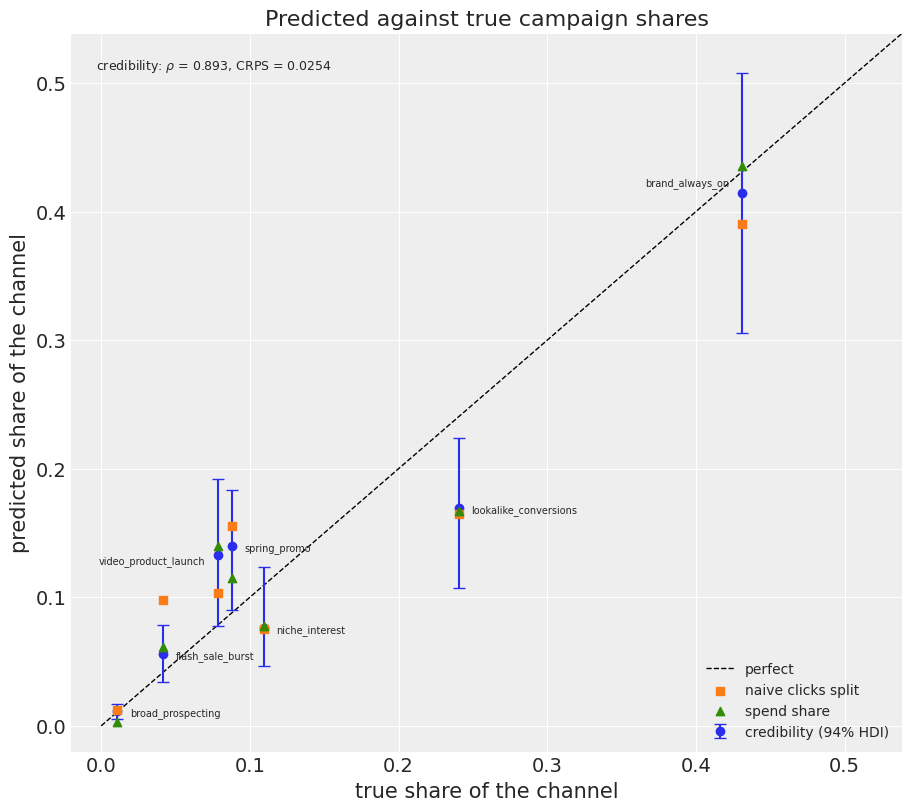

In [27]:
fig, ax = plt.subplots(figsize=(9, 8), layout="constrained")
# one square window wide enough for the widest HDI, so no interval is clipped
upper = 1.06 * max(
    results[["true_share", "credibility_share", "hdi_high"]].to_numpy().max(),
    click_split.max(),
    baselines["spend share"].max(),
)
limits = (-0.02, upper)
ax.plot((0, upper), (0, upper), color="black", ls="--", lw=1.0, label="perfect")
ax.errorbar(
    results["true_share"],
    results["credibility_share"],
    yerr=[
        results["credibility_share"] - results["hdi_low"],
        results["hdi_high"] - results["credibility_share"],
    ],
    fmt="o",
    capsize=4,
    color="C0",
    label=f"credibility ({CI_PROB:.0%} HDI)",
)
ax.scatter(
    true_share,
    click_split,
    marker="s",
    color="C1",
    zorder=3,
    label="naive clicks split",
)
ax.scatter(
    true_share,
    baselines["spend share"],
    marker="^",
    color="C2",
    zorder=3,
    label="spend share",
)
label_offsets = {"video_product_launch": (-9, -6), "brand_always_on": (-9, 6)}
for campaign in campaigns:
    offset = label_offsets.get(campaign, (9, -3))
    ax.annotate(
        campaign,
        (true_share[campaign], results.loc[campaign, "credibility_share"]),
        xytext=offset,
        textcoords="offset points",
        ha="left" if offset[0] > 0 else "right",
        fontsize=7,
    )
credibility_scores = score_shares(true_share, share.to_numpy())
ax.annotate(
    f"credibility: $\\rho$ = {credibility_scores['spearman']:.3f}, "
    f"CRPS = {credibility_scores['crps']:.4f}",
    (0.03, 0.95),
    xycoords="axes fraction",
    fontsize=9,
)
ax.set(
    xlim=limits,
    ylim=limits,
    xlabel="true share of the channel",
    ylabel="predicted share of the channel",
    title="Predicted against true campaign shares",
)
_ = ax.legend(loc="lower right", fontsize=10)

> **Fig.** Predicted against true flight shares, with the 94% HDI on the credibility estimate. Points above the dashed line are over-credited and points below it are under-credited. `lookalike_conversions` is the largest miss, under-credited by 0.07 in share, followed by `spring_promo` and `video_product_launch` over-credited by about 0.05 each. `broad_prospecting` lands almost exactly and `brand_always_on` within 0.02. The naive clicks split (squares) is further from the line on six of the seven campaigns.

The same comparison, campaign by campaign, with the interval laid flat so the coverage count can be read off directly:

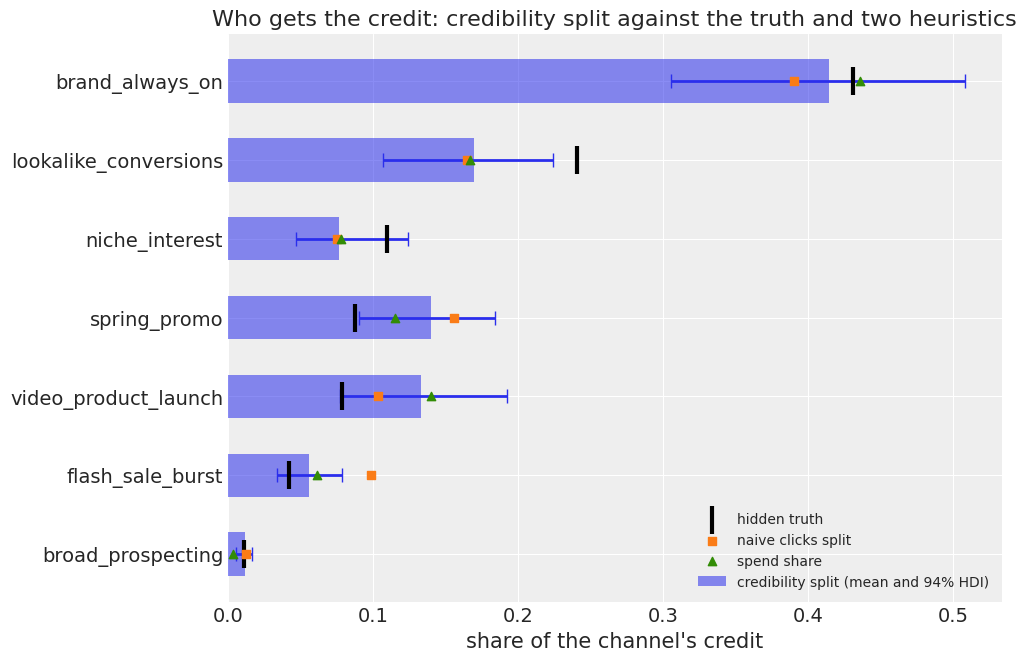

In [28]:
bar_order = results.index[::-1]
bar_positions = np.arange(len(bar_order))
credibility_bars = results.loc[bar_order, "credibility_share"]

fig, ax = plt.subplots(figsize=(10, 6.5), layout="constrained")
ax.barh(
    bar_positions,
    credibility_bars,
    height=0.55,
    color="C0",
    alpha=0.55,
    label=f"credibility split (mean and {CI_PROB:.0%} HDI)",
)
ax.errorbar(
    credibility_bars,
    bar_positions,
    xerr=[
        credibility_bars - results.loc[bar_order, "hdi_low"],
        results.loc[bar_order, "hdi_high"] - credibility_bars,
    ],
    fmt="none",
    ecolor="C0",
    elinewidth=2,
    capsize=5,
)
ax.scatter(
    true_share[bar_order],
    bar_positions,
    marker="|",
    s=420,
    linewidths=3,
    color="black",
    label="hidden truth",
    zorder=4,
)
ax.scatter(
    click_split[bar_order],
    bar_positions,
    marker="s",
    color="C1",
    label="naive clicks split",
    zorder=4,
)
ax.scatter(
    baselines["spend share"][bar_order],
    bar_positions,
    marker="^",
    color="C2",
    label="spend share",
    zorder=4,
)
ax.set(
    yticks=bar_positions,
    yticklabels=bar_order,
    xlabel="share of the channel's credit",
    title="Who gets the credit: credibility split against the truth and two heuristics",
)
_ = ax.legend(loc="lower right", fontsize=10)

> **Fig.** Each campaign's share of the channel under the credibility split (bar, with its 94% HDI as a whisker), against the hidden truth (black tick), the naive clicks split (square) and the spend share (triangle). The truth tick sits inside the whisker for five of the seven campaigns; `lookalike_conversions` and `spring_promo` are the two misses, and both marginal cases are close: `spring_promo` misses its interval by 0.003 in share while `video_product_launch` makes it by 0.001. Where the square sits far from the tick and the bar sits between them, credibility has moved the answer in the right direction without going far enough.

### Sweeping the dial by hand

The most useful validation in the notebook grades the *method* rather than one point estimate. If every campaign were given the same trust level $Z$, from 0 (the delivery split) to 1 (the click split), how would each setting score against the truth? The fitted model never saw the truth, so where its campaign-specific dials land relative to this sweep is a fair test.

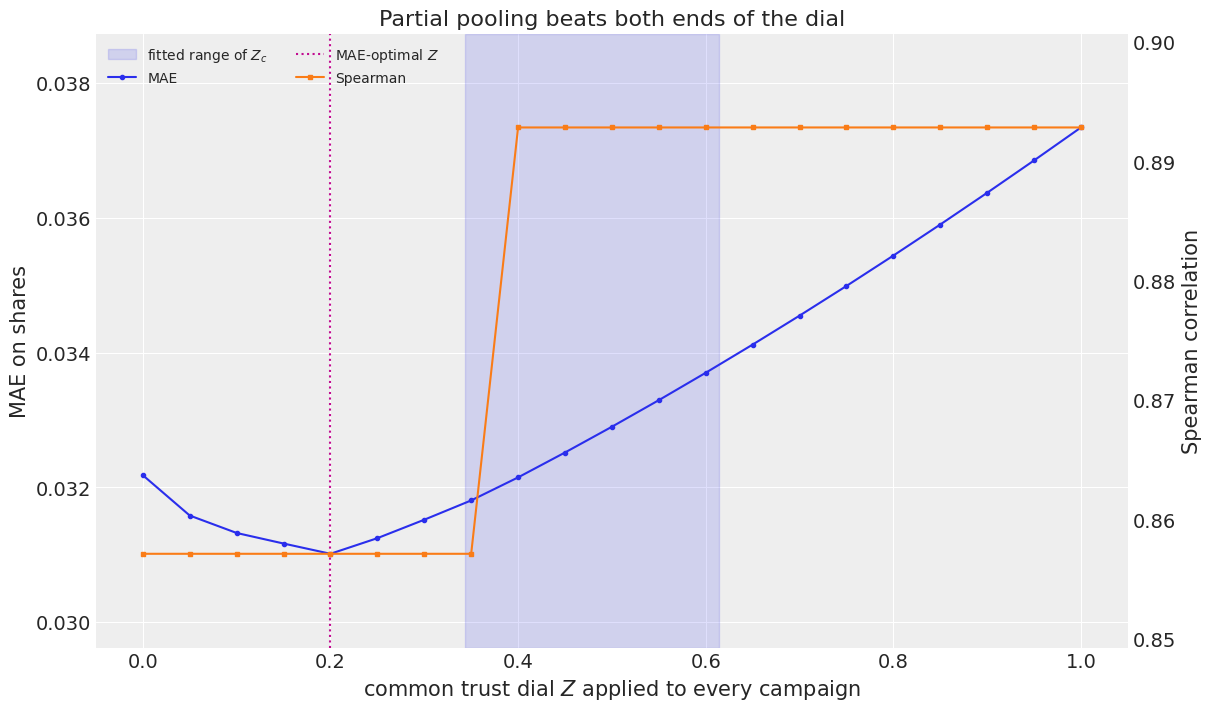

In [29]:
def share_at_common_z(z: float) -> pd.Series:
    """Flight shares if every campaign were trusted by exactly the same amount z."""
    # The blend's (1 - z) * mu term is deliberately dropped: it is the same constant on
    # every theta, so it cancels in the normalisation that turns scores into shares.
    theta_z = xr.DataArray(
        z * y_direct.to_numpy()[None, :],
        dims=("sample", "campaign"),
        coords={"sample": [0], "campaign": campaigns},
    )
    mean_social = social_draws.mean("sample")
    shares = flight_share(allocate(mean_social, allocation_weights(theta_z, reach)))
    return shares.isel(sample=0).to_pandas().reindex(campaigns)


dial_grid = np.linspace(0.0, 1.0, 21)
sweep = pd.DataFrame(
    [
        {
            "Z": z,
            **{
                key: value
                for key, value in score_shares(
                    true_share, share_at_common_z(z).to_numpy()[None, :]
                ).items()
                if key in {"mae", "spearman"}
            },
        }
        for z in dial_grid
    ]
).set_index("Z")

fig, ax_mae = plt.subplots(figsize=(12, 7), layout="constrained")
ax_rho = ax_mae.twinx()
ax_mae.axvspan(
    trust.min(),
    trust.max(),
    color="C0",
    alpha=0.15,
    label="fitted range of $Z_c$",
)
ax_mae.plot(sweep.index, sweep["mae"], color="C0", marker="o", ms=3, label="MAE")
ax_rho.plot(
    sweep.index, sweep["spearman"], color="C1", marker="s", ms=3, label="Spearman"
)
ax_mae.axvline(sweep["mae"].idxmin(), color="C3", ls=":", label="MAE-optimal $Z$")
ax_mae.set(
    xlabel="common trust dial $Z$ applied to every campaign",
    ylabel="MAE on shares",
    title="Partial pooling beats both ends of the dial",
)
ax_rho.set(ylabel="Spearman correlation")
ax_rho.grid(visible=False)
ax_mae.margins(y=0.22)
ax_rho.margins(y=0.22)
handles, labels = (
    left + right
    for left, right in zip(
        ax_mae.get_legend_handles_labels(),
        ax_rho.get_legend_handles_labels(),
        strict=True,
    )
)
_ = ax_mae.legend(handles, labels, loc="upper left", ncol=2, fontsize=10)

> **Fig.** The credibility dial swept by hand, against the hidden truth. It says three things.
>
> Partial pooling beats **both** extremes of the dial on MAE, with an interior minimum of 0.0310 near $Z=0.20$ against 0.0322 at $Z=0$ (the delivery split) and 0.0373 at $Z=1$ (the click split). An interior answer is the right kind of answer here.
>
> Spearman is a step function: the ranking only becomes correct once $Z$ passes about 0.40, which is where two campaigns swap places.
>
> The two criteria therefore disagree, and the fitted range, shaded from 0.34 to 0.61, straddles that step and sits well above the MAE optimum. That is the honest reading of the 0.0347 in the scoreboard: a common dial near 0.20 would have scored better on MAE while getting the order wrong, and the fitted model, which never sees the truth, lands on the side of the step that gets the order right.

### Is the daily shape right?

The stacked figure in Step 3 takes for granted that the day-to-day shape of each campaign's credit is right. Now that we may look at the truth, we can check: how well does each campaign's daily credit track its true daily contribution?

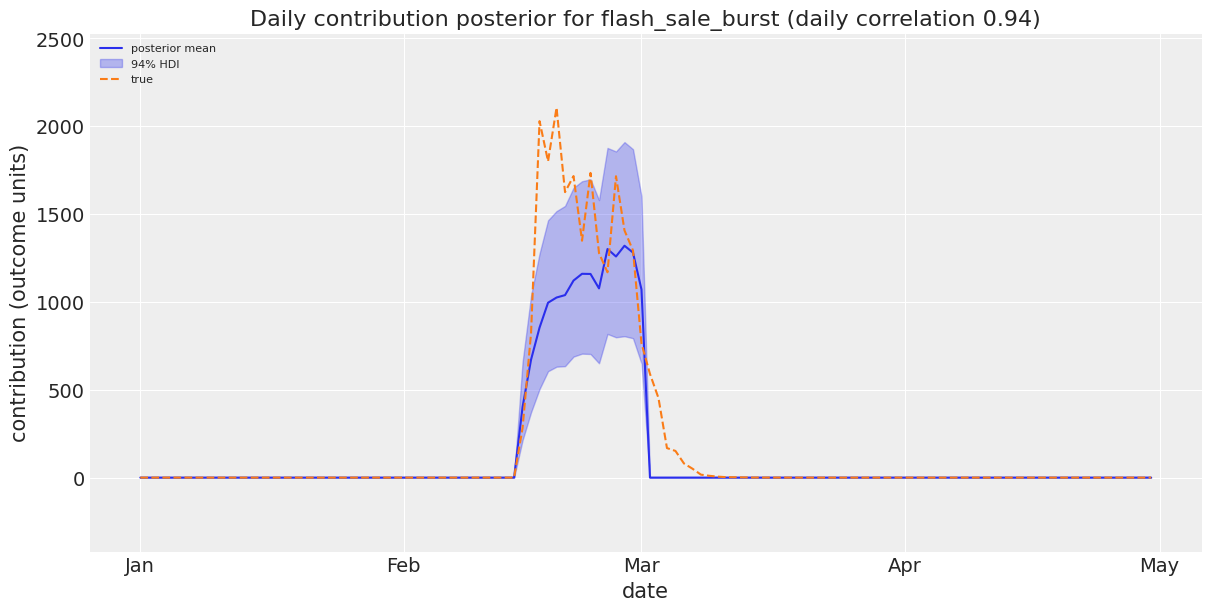

In [30]:
daily_correlation = pd.Series(
    {
        campaign: float(
            np.corrcoef(
                daily_mean.sel(campaign=campaign).to_numpy(),
                data.truth[campaign].to_numpy(),
            )[0, 1]
        )
        for campaign in campaigns
    }
).sort_values(ascending=False)

focus = "flash_sale_burst"
focus_daily = contribution.sel(campaign=focus)
focus_bounds = az.hdi(focus_daily, dim="sample")

fig, ax = plt.subplots(figsize=(12, 6), layout="constrained")
ax.plot(
    reach.date,
    focus_daily.mean("sample").to_numpy(),
    color="C0",
    label="posterior mean",
)
ax.fill_between(
    reach.date,
    focus_bounds.sel(ci_bound="lower").to_numpy(),
    focus_bounds.sel(ci_bound="upper").to_numpy(),
    color="C0",
    alpha=0.3,
    label=f"{CI_PROB:.0%} HDI",
)
ax.plot(
    data.truth.index, data.truth[focus].to_numpy(), color="C1", ls="--", label="true"
)
ax.set(
    title=f"Daily contribution posterior for {focus} "
    f"(daily correlation {daily_correlation[focus]:.2f})",
    xlabel="date",
    ylabel="contribution (outcome units)",
)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.margins(y=0.20)
_ = ax.legend(loc="upper left", fontsize=8)

In [31]:
daily_correlation.rename("daily correlation with the truth").round(2)

flash_sale_burst         0.94
spring_promo             0.91
video_product_launch     0.89
broad_prospecting        0.86
brand_always_on          0.77
lookalike_conversions    0.56
niche_interest           0.28
Name: daily correlation with the truth, dtype: float64

> **Fig.** The daily posterior for `flash_sale_burst` against the hidden truth. Notice the tail: the truth decays for about a week after the burst stops, while our allocation drops to exactly zero the day delivery ends, because the daily shape is inherited from daily reach.

The correlations measure the same thing for every campaign. The inherited shape holds well for five campaigns, from `flash_sale_burst` at 0.94 down to `brand_always_on` at 0.77, and poorly for `lookalike_conversions` at 0.56 and `niche_interest` at 0.28. That is the expected failure mode: the daily shape is inherited entirely from daily reach, so a campaign whose true impact does not track its delivery cannot be fixed by any reweighting of the level. The missing tail, however, is repairable, and the MMM already tells us how.

## Extension: letting the credit outlive the flight

The daily allocation spends each day's MMM credit in proportion to that day's raw reach, so a campaign's credit stops dead the moment its delivery does. The MMM itself disagrees: it was fit with a geometric adstock on the channel's media variable, so the channel curve it hands us already contains carryover, revenue arriving days after the exposure that caused it. Splitting an adstocked curve by un-adstocked reach hands the tail of every burst to whichever campaigns happen to still be delivering.

This is also the answer to a fair objection raised about the method: the split should be **aligned with the MMM's own structure**, not just anchored to its total. The repair is one line: push each campaign's daily reach through the **same transform the MMM used**, {func}`geometric adstock <pymc_marketing.mmm.transformers.geometric_adstock>`, before computing the daily weights. Because the weights are renormalised every day, the split still reconciles to the MMM total exactly; only the *shape* of each campaign's credit changes. And crucially, the decay rate is not a new free dial to agonise over. Your fitted MMM has a posterior for the channel's adstock decay (`adstock_alpha` in PyMC-Marketing), and inheriting it is precisely what "aligned with the main model's structure" means.

The data package here ships only the contribution curve, not the fitted decay, so this notebook does the next best thing: sweep the decay rate and grade each setting against the hidden truth, the same oracle-grading already used for the $Z$ sweep. Two caveats to read alongside the table. This grading is a validation your own data cannot repeat, which is why the production recommendation is to inherit the MMM's decay rather than tune it. And in this simulation each campaign's true carryover decays at its own rate, so a single channel-level decay, which is all a channel-level MMM can offer, is itself an approximation.

In [32]:
def adstocked_reach(reach: xr.DataArray, alpha: float, l_max: int = 12) -> xr.DataArray:
    """Daily reach pushed through the MMM's geometric adstock along the date axis."""
    values = (
        geometric_adstock(
            ptx.as_xtensor(pt.as_tensor_variable(reach.to_numpy()), dims=reach.dims),
            alpha=alpha,
            l_max=l_max,
            normalize=True,
            dim="date",
        )
        .transpose(*reach.dims)
        .eval()
    )
    return xr.DataArray(values, dims=reach.dims, coords=reach.coords)


def daily_truth_correlation(contribution: xr.DataArray) -> pd.Series:
    """Correlation of each campaign's posterior-mean daily credit with the truth."""
    daily = contribution.mean("sample")
    return pd.Series(
        {
            campaign: float(
                np.corrcoef(
                    daily.sel(campaign=campaign).to_numpy(),
                    data.truth[campaign].to_numpy(),
                )[0, 1]
            )
            for campaign in campaigns
        }
    )


def evaluate_decay(alpha: float) -> dict[str, float]:
    """Allocate with adstocked reach at one decay rate and grade the result."""
    contribution_alpha = allocate(
        social_draws, allocation_weights(theta_draws, adstocked_reach(reach, alpha))
    )
    correlations = daily_truth_correlation(contribution_alpha)
    shares = flight_share(contribution_alpha).transpose("sample", "campaign")
    scores = score_shares(true_share, shares.to_numpy())
    return {
        "mean_daily_corr": float(correlations.mean()),
        **{f"corr_{campaign}": correlations[campaign] for campaign in campaigns},
        "spearman": scores["spearman"],
        "mae": scores["mae"],
        "crps": scores["crps"],
    }


decay_grid = (0.0, 0.2, 0.4, 0.6, 0.8)
corr_columns = [f"corr_{campaign}" for campaign in campaigns]
adstock_sweep = pd.DataFrame(
    [{"alpha": alpha, **evaluate_decay(alpha)} for alpha in decay_grid]
).set_index("alpha")
adstock_sweep.round(3)

,mean_daily_corr,corr_brand_always_on,corr_spring_promo,corr_lookalike_conversions,corr_video_product_launch,corr_flash_sale_burst,corr_niche_interest,corr_broad_prospecting,spearman,mae,crps
alpha,,,,,,,,,,,
0.0,0.744,0.774,0.912,0.559,0.885,0.939,0.285,0.856,0.893,0.035,0.025
0.2,0.761,0.796,0.914,0.590,0.895,0.944,0.317,0.870,0.893,0.035,0.026
0.4,0.779,0.816,0.912,0.634,0.903,0.942,0.359,0.887,0.893,0.035,0.026
0.6,0.797,0.834,0.900,0.695,0.905,0.923,0.414,0.908,0.893,0.036,0.026
0.8,0.787,0.824,0.858,0.729,0.876,0.856,0.434,0.929,0.893,0.036,0.027


In [33]:
def mean_share_at(alpha: float) -> pd.Series:
    """Posterior-mean flight share of each campaign at one decay rate."""
    weights = allocation_weights(theta_draws, adstocked_reach(reach, alpha))
    return (
        flight_share(allocate(social_draws, weights))
        .mean("sample")
        .to_pandas()
        .reindex(campaigns)
    )


best_alpha = float(adstock_sweep["mean_daily_corr"].idxmax())
display_alpha = best_alpha if best_alpha > 0 else 0.4
corr_change = pd.Series(
    (
        adstock_sweep.loc[display_alpha, corr_columns]
        - adstock_sweep.loc[0.0, corr_columns]
    ).to_numpy(),
    index=campaigns,
).sort_values(ascending=False)
share_shift = float((mean_share_at(display_alpha) - mean_share_at(0.0)).abs().max())

print(
    f"Best decay rate by mean daily correlation: {best_alpha:.1f}. Largest change in any "
    f"campaign's mean flight share between no carryover and that decay: {share_shift:.4f}."
)
corr_change.rename(
    f"change in daily correlation, decay {display_alpha:.1f} vs 0"
).round(2)

Best decay rate by mean daily correlation: 0.6. Largest change in any campaign's mean flight share between no carryover and that decay: 0.0026.


lookalike_conversions    0.14
niche_interest           0.13
brand_always_on          0.06
broad_prospecting        0.05
video_product_launch     0.02
spring_promo            -0.01
flash_sale_burst        -0.02
Name: change in daily correlation, decay 0.6 vs 0, dtype: float64

The sweep favours carrying credit forward: the mean daily correlation with the truth rises from 0.744 with no carryover to 0.797 at a decay rate of 0.6 (row `alpha = 0.0` reproduces the raw-reach allocation exactly, since a zero decay is the identity). The campaigns that gain are the ones whose credit had been stopping dead: `lookalike_conversions` +0.14, `niche_interest` +0.13, `brand_always_on` +0.06, `broad_prospecting` +0.05, `video_product_launch` +0.02. The correction is not free everywhere: `flash_sale_burst` loses 0.02 and `spring_promo` 0.01, because at a decay of 0.6 their tails are stretched slightly further than the truth's. Window-total shares barely move: the largest change in any campaign's mean flight share between no carryover and a decay of 0.6 is 0.0026, so this is a repair to *when* the credit lands, not to *who* gets it. The scoreboard columns confirm it: Spearman, MAE and CRPS are essentially flat across the decay grid.

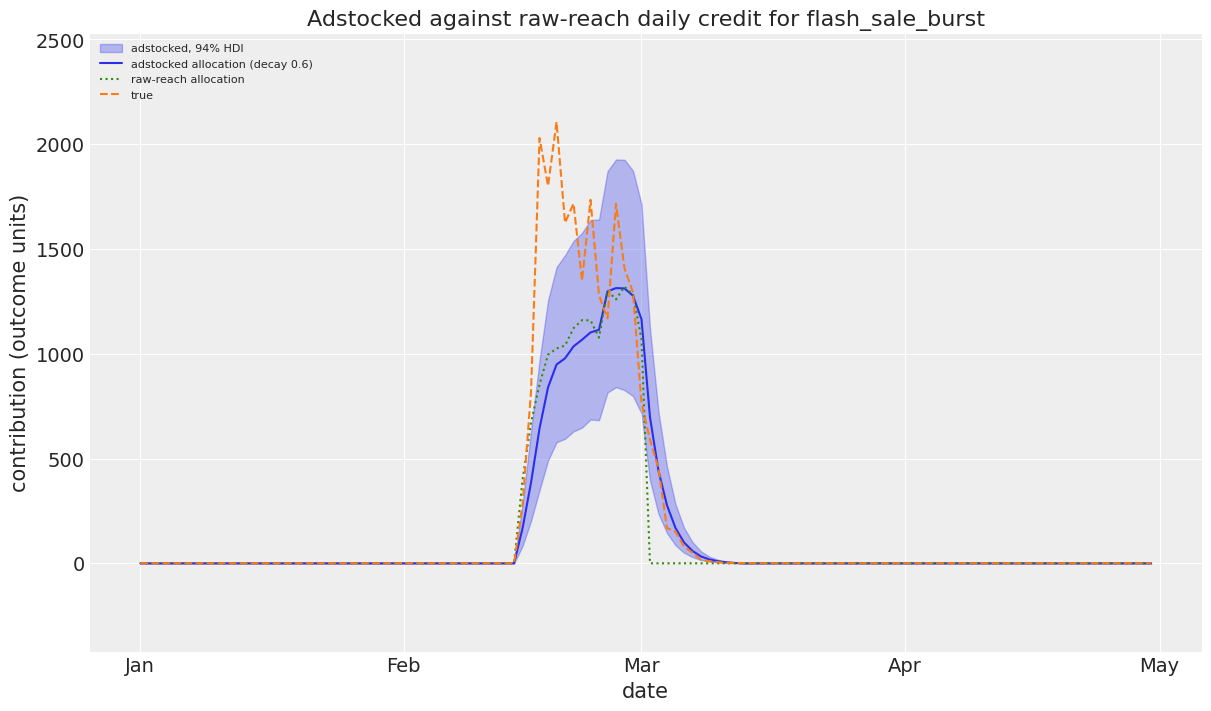

In [34]:
adstock_contribution = allocate(
    social_draws, allocation_weights(theta_draws, adstocked_reach(reach, display_alpha))
)
focus = "flash_sale_burst"
focus_adstock = adstock_contribution.sel(campaign=focus)
focus_adstock_bounds = az.hdi(focus_adstock, dim="sample")

fig, ax = plt.subplots(figsize=(12, 7), layout="constrained")
ax.fill_between(
    reach.date,
    focus_adstock_bounds.sel(ci_bound="lower").to_numpy(),
    focus_adstock_bounds.sel(ci_bound="upper").to_numpy(),
    color="C0",
    alpha=0.3,
    label=f"adstocked, {CI_PROB:.0%} HDI",
)
ax.plot(
    reach.date,
    focus_adstock.mean("sample").to_numpy(),
    color="C0",
    label=f"adstocked allocation (decay {display_alpha:.1f})",
)
ax.plot(
    reach.date,
    contribution.sel(campaign=focus).mean("sample").to_numpy(),
    color="C2",
    ls=":",
    label="raw-reach allocation",
)
ax.plot(
    data.truth.index, data.truth[focus].to_numpy(), color="C1", ls="--", label="true"
)
ax.set(
    title=f"Adstocked against raw-reach daily credit for {focus}",
    xlabel="date",
    ylabel="contribution (outcome units)",
)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.margins(y=0.20)
_ = ax.legend(loc="upper left", fontsize=8)

> **Fig.** The `flash_sale_burst` daily credit under the adstocked allocation, against the raw-reach allocation and the hidden truth. By construction the adstocked credit decays after the flight ends instead of stopping dead; how well that tail matches the truth is what the sweep table above measures. One boundary artefact is worth knowing about: adstocked reach ramps up from an empty history at the left edge of the window, while the true carryover of the always-on campaigns is already at steady state there, so the first stretch of the window is where this correction is least trustworthy.

## Robustness checks

A sceptical reader has three fair questions at this point, and each deserves a test rather than a shrug.

1. The fitted dial's band was wide. **How much of the answer is the prior?**
2. We *asserted* that unique reach is the evidence and reach-days are the exposure. **Is that choice doing real work, or would the delivery measure do just as well?**
3. The seven shares add to one, so the model's assumption that the seven campaign signals are independent is not literally true. **Does ignoring that hurt?**

All three checks re-fit the model and re-grade the split with the Step 3 (raw reach) allocation, because the adstock extension showed that adstock changes *when* the credit lands and not *who* gets it. Questions 2 and 3 are, in different ways, both stress tests of the notebook's thesis that reach is evidence.

### How much of the answer is the prior?

The dropdown in Step 2 explained why $k$ and $s^2$ are only weakly separated by seven campaigns, which is exactly the situation in which priors can quietly steer the answer. So we vary both priors that touch the dial, the scale of `sigma_s` and the width of the prior on $\log k$, and grade every combination.

In [35]:
def evaluate_variant(
    volume: pd.Series,
    *,
    sigma_s_scale: float = 0.5,
    log_k_sd: float = 0.75,
    run_seed: int = seed,
) -> dict[str, float]:
    """Fit one configuration end to end and grade the split it produces."""
    model = build_credibility_model(
        y_direct, volume, sigma_s_scale=sigma_s_scale, log_k_sd=log_k_sd
    )
    variant = fit_credibility(model, sample_seed=run_seed, progressbar=False)
    variant_social, variant_theta = paired_draws(
        data.social, variant.posterior["theta"], pair_seed=run_seed
    )
    variant_share = flight_share(
        allocate(variant_social, allocation_weights(variant_theta, reach))
    ).transpose("sample", "campaign")
    dial = variant.posterior["Z"].mean(("chain", "draw")).to_numpy()
    return {
        "divergences": int(variant.sample_stats["diverging"].sum()),
        "k_median": float(variant.posterior["k"].median()) * float(volume.mean()),
        "Z_min": float(dial.min()),
        "Z_max": float(dial.max()),
        **score_shares(true_share, variant_share.to_numpy()),
    }


prior_sensitivity = pd.DataFrame(
    [
        {
            "sigma_s": sigma_s_scale,
            "sd_log_k": log_k_sd,
            **evaluate_variant(
                unique_reach, sigma_s_scale=sigma_s_scale, log_k_sd=log_k_sd
            ),
        }
        for sigma_s_scale in (0.4, 0.5, 0.7)
        for log_k_sd in (0.5, 0.75)
    ]
).set_index(["sigma_s", "sd_log_k"])
prior_sensitivity.round(4)

NUTS[nutpie]: [mu, log_k, sigma_s, theta_raw]


NUTS[nutpie]: [mu, log_k, sigma_s, theta_raw]


NUTS[nutpie]: [mu, log_k, sigma_s, theta_raw]


NUTS[nutpie]: [mu, log_k, sigma_s, theta_raw]


NUTS[nutpie]: [mu, log_k, sigma_s, theta_raw]


NUTS[nutpie]: [mu, log_k, sigma_s, theta_raw]


divergences    k_median   Z_min   Z_max  spearman     mae  \
sigma_s sd_log_k                                                              
0.4     0.50                0  36681.0065  0.3367  0.6223    0.8929  0.0341   
        0.75                0  37336.0913  0.3405  0.6105    0.8929  0.0338   
0.5     0.50                0  37399.0742  0.3328  0.6177    0.8929  0.0348   
        0.75                0  37060.9792  0.3434  0.6138    0.8929  0.0347   
0.7     0.50                0  37831.6077  0.3297  0.6145    0.8929  0.0343   
        0.75                0  39093.8979  0.3335  0.6019    0.8929  0.0346   

                    crps  coverage  
sigma_s sd_log_k                    
0.4     0.50      0.0251       5.0  
        0.75      0.0245       6.0  
0.5     0.50      0.0249       5.0  
        0.75      0.0254       5.0  
0.7     0.50      0.0247       6.0  
        0.75      0.0252       5.0

The ranking is identical across all six settings, MAE stays between 0.0338 and 0.0348 and CRPS between 0.0245 and 0.0254, so the conclusions are not a prior artefact. The evidence threshold drifts from 36,681 to 39,094 people, about 7%, upward with the prior scale on `sigma_s`, which is the weak identification showing up as mild prior sensitivity exactly where the algebra said it would. No configuration produced a single divergence. Coverage sits at 5 of 7 in four settings and 6 of 7 in two, with no pattern, which is the fragility flagged in the grading section.

:::{admonition} What we learn
:class: note
The prior nudges the threshold $k$ by a few thousand people and leaves the ranking, the share errors and the probabilistic score essentially untouched. The dial is set by the data, not by us.
:::

### Is unique reach really the right evidence?

The "Two quantities" callout in the EDA asserted that unique people, not reach-days, are the evidence. That is directly testable: swap the volume measure that sets $Z$ from unique reach $n_c$ to reach-days $R_c$, at three seeds so that sampling noise is not mistaken for a result. The `k_median` column is in the units of whichever measure sets the dial, so it reads as people in the first block and as reach-days in the second.

In [36]:
evidence_choice = pd.DataFrame(
    [
        {
            "volume": name,
            "seed": run_seed,
            **evaluate_variant(volume, run_seed=run_seed),
        }
        for name, volume in [
            ("unique reach (evidence)", unique_reach),
            ("reach-days (delivery)", direct["reach_days"]),
        ]
        for run_seed in (42, 1, 7)
    ]
).set_index(["volume", "seed"])
evidence_choice.round(4)

NUTS[nutpie]: [mu, log_k, sigma_s, theta_raw]


NUTS[nutpie]: [mu, log_k, sigma_s, theta_raw]


NUTS[nutpie]: [mu, log_k, sigma_s, theta_raw]


NUTS[nutpie]: [mu, log_k, sigma_s, theta_raw]


NUTS[nutpie]: [mu, log_k, sigma_s, theta_raw]


NUTS[nutpie]: [mu, log_k, sigma_s, theta_raw]


divergences     k_median   Z_min   Z_max  \
volume                  seed                                             
unique reach (evidence) 42              0   37060.9792  0.3434  0.6138   
                        1               0   38103.5874  0.3360  0.6070   
                        7               0   40297.8043  0.3279  0.5975   
reach-days (delivery)   42              1  587708.0941  0.0667  0.7045   
                        1               0  573633.5694  0.0677  0.7096   
                        7               0  582217.3447  0.0656  0.7026   

                              spearman     mae    crps  coverage  
volume                  seed                                      
unique reach (evidence) 42      0.8929  0.0347  0.0254       5.0  
                        1       0.8929  0.0345  0.0254       4.0  
                        7       0.8929  0.0350  0.0253       4.0  
reach-days (delivery)   42      0.8929  0.0327  0.0251       3.0  
                        1       0.8929  0.0319  0.0246       3.0  
                        7       0.8929  0.0324  0.0248       4.0

Read that honestly: **this dataset does not settle the question, and on the graded scores it mildly favours the delivery measure.** Driving the dial by reach-days gives the same ranking at 0.893, a CRPS of 0.0246 to 0.0251 against 0.0253 to 0.0254, slightly better MAE at 0.0319 to 0.0327 against 0.0345 to 0.0350, and coverage of 3 to 4 of 7 against 4 to 5 of 7. With only seven campaigns we cannot separate two measures that are this strongly correlated with each other. The reach-days fits are also the harder ones to sample, with 1 divergence across the three seeds against 0 for unique reach. What the table does establish is stability: three independently seeded fits move MAE and CRPS by at most 0.0008, and the coverage count by at most one campaign.

Look at the `Z_min` and `Z_max` columns, though. With reach-days as the evidence the dial spreads from 0.07 to 0.71, because reach-days span a factor of 47 across campaigns where unique reach spans 3.5. In practice that means `brand_always_on` would be believed almost fully, not because it reached the most people but because it re-hit the same people 25 times each, while `broad_prospecting` would be nearly ignored despite reaching 24k distinct people in 30 days. That is the delivery measure rewarding how hard we pushed, not how much we learned.

:::{admonition} What we learn
:class: note
We are overriding a small score difference on conceptual grounds, and it is worth being explicit about that. A person re-reached tomorrow adds delivery but no new information about the campaign, so unique reach is the quantity that answers "how much do I know about this campaign?", which is what a credibility volume measure is supposed to be. An MAE gap of 0.0024 on seven campaigns is not the kind of evidence that should redefine what evidence means.
:::

### Does ignoring the composition hurt?

The seven naive rates come from seven click shares that add to one, so they are slices of one pie: if one slice is too big, the others must be too small. The model treats the seven signals as independent and ignores that built-in push-and-pull. Here we fit two variants that respect the pie and grade them on the same scoreboard.

- **A compositional twin with the same trust dial.** Same model, same hierarchy, same evidence-based $Z_c$, but the likelihood is written on the *differences* between each campaign's signal and a reference campaign, which is what a set of shares actually pins down. If ignoring the composition mattered, this twin would move the split.
- **A model of the click counts themselves.** The textbook way to model a pie of counts is a Dirichlet-multinomial on the raw clicks, with the same hierarchy on effectiveness. The catch is what plays the role of evidence: in this likelihood a share's noise shrinks with the number of *clicks*, so a campaign with thousands of clicks looks precisely measured whether or not its clicks mean anything. That is the strongest possible test of "reach is evidence", because it swaps reach out for clicks.

:::{dropdown} For the statistically minded: the two likelihoods
**ALR logistic-normal twin.** Suppose each campaign's *unnormalised* log signal is $z_c=\theta_c+\varepsilon_c$ with the familiar reach-scaled noise $\varepsilon_c\sim\text{Normal}(0,\psi_c)$, and the observed click shares are the softmax of the $z$'s. Then the six observable contrasts $y_c-y_{\text{ref}}$ are multivariate normal with mean $\theta_c-\theta_{\text{ref}}$ and covariance $\operatorname{diag}(\psi_{-\text{ref}})+\psi_{\text{ref}}\mathbf{1}\mathbf{1}^{\top}$, and that rank-one term is exactly the induced negative dependence. The implementation never writes that matrix down: conditional on the reference campaign's own noise $\varepsilon_{\text{ref}}$, the contrasts are independent Normals sharing the $-\varepsilon_{\text{ref}}$ shift, so one extra scalar latent reproduces the covariance exactly. Nothing else changes: same hierarchy, same $\psi_c=s^2/n^{\text{rel}}_c$, same dial $Z_c$. The likelihood now only identifies *contrasts* of $\theta$, so $\mu$ stays close to its prior, but the daily allocation is invariant to a common shift of $\theta$ (the softmax eats it), so nothing downstream is lost. It also makes explicit that the seven $y_c$ carry only six degrees of freedom, since $\sum_c R_c\,e^{y_c}=T$ holds by construction.

**Dirichlet-multinomial.** $\text{clicks}\sim\text{DirichletMultinomial}(N,\kappa\,p)$ with $p_c\propto R_c\,e^{\theta_c}$ and the same hierarchy on $\theta$. The concentration $\kappa$ is asked to learn the overdispersion from a single observed composition, and whether that leaves any room for reach to set the trust is exactly what the comparison measures.
:::

In [37]:
def build_compositional_model(
    y_direct: pd.Series,
    volume: pd.Series,
    *,
    sigma_s_scale: float = 0.5,
    log_k_sd: float = 0.75,
) -> pm.Model:
    """ALR logistic-normal twin of the credibility model, same trust dial."""
    campaigns = list(y_direct.index)
    volume_relative = (volume / volume.mean()).reindex(campaigns).to_numpy()
    y_alr = (y_direct.iloc[:-1] - y_direct.iloc[-1]).to_numpy()
    with pm.Model(coords={"campaign": campaigns, "contrast": campaigns[:-1]}) as model:
        mu = pm.Normal("mu", mu=float(y_direct.mean()), sigma=1.0)
        log_k = pm.Normal("log_k", 0.0, log_k_sd)
        k = pm.Deterministic("k", pm.math.exp(log_k))
        sigma_s = pm.HalfNormal("sigma_s", sigma_s_scale)
        s2 = pm.Deterministic("s2", sigma_s**2)
        pm.Deterministic("tau", pm.math.sqrt(s2 / k))
        psi = s2 / volume_relative
        pm.Deterministic("Z", volume_relative / (volume_relative + k), dims="campaign")
        theta_raw = pm.Normal("theta_raw", 0.0, 1.0, dims="campaign")
        theta = pm.Deterministic(
            "theta", mu + pm.math.sqrt(s2 / k) * theta_raw, dims="campaign"
        )
        # the reference campaign's own noise, shared by every contrast: this scalar
        # latent IS the rank-one negative dependence, without writing the matrix down
        eps_ref = pm.Normal("eps_ref", 0.0, pm.math.sqrt(psi[-1]))
        pm.Normal(
            "y_alr_obs",
            mu=theta[:-1] - theta[-1] - eps_ref,
            sigma=pm.math.sqrt(psi[:-1]),
            observed=y_alr,
            dims="contrast",
        )
    return model


def build_dirichlet_multinomial_model(
    clicks: pd.Series,
    exposure: pd.Series,
    *,
    sigma_s_scale: float = 0.5,
    log_k_sd: float = 0.75,
) -> pm.Model:
    """Dirichlet-multinomial on click counts, same hierarchy on theta."""
    campaigns = list(clicks.index)
    log_exposure = np.log((exposure / exposure.mean()).reindex(campaigns).to_numpy())
    with pm.Model(coords={"campaign": campaigns}) as model:
        mu = pm.Normal("mu", 0.0, 1.0)
        log_k = pm.Normal("log_k", 0.0, log_k_sd)
        k = pm.Deterministic("k", pm.math.exp(log_k))
        sigma_s = pm.HalfNormal("sigma_s", sigma_s_scale)
        s2 = pm.Deterministic("s2", sigma_s**2)
        pm.Deterministic("tau", pm.math.sqrt(s2 / k))
        theta_raw = pm.Normal("theta_raw", 0.0, 1.0, dims="campaign")
        theta = pm.Deterministic(
            "theta", mu + pm.math.sqrt(s2 / k) * theta_raw, dims="campaign"
        )
        kappa = pm.LogNormal("kappa", mu=np.log(1_000.0), sigma=2.0)
        p = pm.math.softmax(theta + log_exposure)
        pm.DirichletMultinomial(
            "clicks_obs",
            n=int(clicks.sum()),
            a=kappa * p,
            observed=clicks.to_numpy(),
            dims="campaign",
        )
    return model


def variant_share(idata: xr.DataTree, *, pair_seed: int) -> xr.DataArray:
    """Flight-share draws implied by one fitted variant's theta posterior."""
    variant_social, variant_theta = paired_draws(
        data.social, idata.posterior["theta"], pair_seed=pair_seed
    )
    return flight_share(
        allocate(variant_social, allocation_weights(variant_theta, reach))
    ).transpose("sample", "campaign")


compositional_idata = fit_credibility(
    build_compositional_model(y_direct, unique_reach), progressbar=False
)
compositional_share = variant_share(compositional_idata, pair_seed=seed)
dm_idata = fit_credibility(
    build_dirichlet_multinomial_model(direct["clicks"], direct["reach_days"]),
    progressbar=False,
)
dm_share = variant_share(dm_idata, pair_seed=seed)

variant_scoreboard = pd.DataFrame(
    [
        {
            "method": name,
            "divergences": int(fit.sample_stats["diverging"].sum()),
            **score_shares(true_share, draws.to_numpy()),
        }
        for name, fit, draws in [
            ("independent Normal (main)", idata, share),
            ("ALR logistic-normal", compositional_idata, compositional_share),
            ("Dirichlet-multinomial", dm_idata, dm_share),
        ]
    ]
).set_index("method")
variant_scoreboard.assign(
    coverage=lambda df: df["coverage"].map("{:.0f} of 7".format)
).round(4)

NUTS[nutpie]: [mu, log_k, sigma_s, theta_raw, eps_ref]


NUTS[nutpie]: [mu, log_k, sigma_s, theta_raw, kappa]


,divergences,spearman,mae,crps,coverage
method,,,,,
independent Normal (main),0,0.8929,0.0347,0.0254,5 of 7
ALR logistic-normal,0,0.8929,0.0343,0.0251,4 of 7
Dirichlet-multinomial,35,0.8929,0.0366,0.0307,3 of 7


In [38]:
alr_share_gap = float(
    (compositional_share.mean("sample").to_pandas() - share.mean("sample").to_pandas())
    .abs()
    .max()
)
dm_click_gap = float((dm_share.mean("sample").to_pandas() - click_split).abs().max())
main_click_gap = float((share.mean("sample").to_pandas() - click_split).abs().max())
kappa_posterior = dm_idata.posterior["kappa"].to_numpy().ravel()
kappa_prior_iqr = float(
    np.exp(np.log(1_000.0) + 2.0 * 0.6745) - np.exp(np.log(1_000.0) - 2.0 * 0.6745)
)
kappa_posterior_iqr = float(
    np.quantile(kappa_posterior, 0.75) - np.quantile(kappa_posterior, 0.25)
)

pd.Series(
    {
        "largest mean-share gap, ALR twin vs main": alr_share_gap,
        "largest mean-share gap, main vs naive click split": main_click_gap,
        "largest mean-share gap, Dirichlet-multinomial vs naive click split": dm_click_gap,
        "kappa prior interquartile range": kappa_prior_iqr,
        "kappa posterior interquartile range": kappa_posterior_iqr,
    },
    name="value",
).round(4)

largest mean-share gap, ALR twin vs main                                 0.0009
largest mean-share gap, main vs naive click split                        0.0422
largest mean-share gap, Dirichlet-multinomial vs naive click split       0.0289
kappa prior interquartile range                                       3594.0704
kappa posterior interquartile range                                   4271.1249
Name: value, dtype: float64

Reading the two tables in both directions.

**The compositional twin changes remarkably little.** The two models are practically the same split: the largest difference in any campaign's mean share is 0.0009. On the graded scores the twin lands at MAE 0.0343, CRPS 0.0251 and Spearman 0.893 against 0.0347, 0.0254 and 0.893 for the independent likelihood, with no divergences in either. The push-and-pull between the slices is real, but with seven campaigns and noise this large it barely moves the split. That is a useful negative result: the independent likelihood is not what stands between this method and better accuracy.

**The Dirichlet-multinomial is the cautionary tale.** Its mean shares end up within 0.0289 of the naive click split, against 0.0422 for the credibility split, so it drifts back toward trusting the dashboard. It scores MAE 0.0366, CRPS 0.0307 and Spearman 0.893, with 35 divergences, so it is both less accurate and harder to sample. And its concentration parameter, the one number that could have added scepticism, is left almost where the prior put it: a posterior interquartile range of 4,271 against 3,594 in the prior. One observed composition cannot teach it how much to distrust clicks, so the amount of trust ends up set by a prior nobody can argue with, not by reach.

:::{admonition} What we learn
:class: note
Respecting the pie is not what limits accuracy here. Swapping reach for clicks as the evidence is what breaks the method: thousands of clicks look precise, but "precise" is not "right". The noise that matters is the gap between clicks and incrementality, and it does not shrink with click volume. Reach measures how much we know; clicks measure how loud the signal is. That is why reach does the disciplining in this notebook, and why it can, precisely because it is not the quantity being divided up.
:::

## What it can and cannot do

:::{admonition} What it is genuinely good at
:class: tip
- **It refuses to be fooled by small, loud campaigns.** The less evidence a campaign has, the harder its wild self-report is reined in, so bursty campaigns stop hijacking the credit. `flash_sale_burst` is the case in point: its naive rate per reach-day is the highest in the account, and the model cuts it by about a third (0.40 log units, a factor of 1.5).
- **It never breaks the budget.** The campaign pieces sum back to the MMM's channel total exactly, every day, to numerical precision. It divides the number you trust rather than inventing a new one.
- **It is the best probabilistic forecast of everything tested here**, at a CRPS of 0.0254 in share units against 0.0321 for the best simple heuristic.
- **The dial it picks is defensible without the oracle.** Sweeping a common $Z$ shows partial pooling beats both extremes, and the fitted dials land in the interior and recover the campaign ranking without ever seeing the truth.
- **It is built on the safest idea in the toolbox**, partial pooling, so it behaves well and is easy to explain to whoever asks.
:::

:::{admonition} What it cannot do (read before trusting)
:class: warning
- **It cures noise, not bias.** It fixes the "small campaigns are jumpy" problem. It does not fix the fact that clicks are not incrementality. `lookalike_conversions` stays under-credited by 0.07 in share (7 percentage points of the channel's credit) and `niche_interest` by 0.03, because **no method that only sees delivery data can recover what delivery data does not contain**.
- **On point accuracy it does not beat a delivery split here.** MAE is 0.0347 against 0.0321 for the daily-reach share, and a common dial near 0.20 would have done better still on MAE while getting the ranking wrong. Its measurable gains are ranking, calibration and a defensible trust weight, not a jump in point accuracy.
- **The daily shape is inherited, not estimated.** Within a campaign the day-to-day pattern is its daily reach, which tracks the truth well for five campaigns and badly for `lookalike_conversions` at 0.56 and `niche_interest` at 0.28. The adstock extension shows how much of that is repairable by inheriting the MMM's carryover, and a campaign whose true impact simply does not track its delivery stays beyond any reweighting.
- **The uncertainty is a lower bound.** Five of seven true shares land inside the 94% HDI, but the interval carries parameter uncertainty only, and the clicks-to-incrementality gap is nowhere in the model.
- **The likelihood ignores that the target is compositional, and we tested the fix.** The compositional twin barely moves the split, so this shortcut is not what limits accuracy here; the Dirichlet-multinomial alternative trades the reach-based dial for a prior-driven one and drifts toward the click split.
- **Evidence can be confounded with a truncated flight.** `broad_prospecting` is the only campaign still acquiring new people when the window closes, so its unique reach measures 30 days of growth rather than a saturated audience. It is discounted for being young as much as for being small, and nothing in the model knows the difference.
- **Only seven campaigns.** The dial's tuning is itself uncertain, the posterior for $k$ says so, and no single synthetic dataset can settle a comparison against any baseline.
:::

:::{admonition} Run it on your own data
:class: tip
1. **Pull expanding-window reach** per campaign: fix the report's start date and extend the end date one day at a time. The day-over-day differences are genuinely new people. This is the `cum_reach` table above.
2. **Build any naive split** of the MMM channel total from what your dashboard already gives you, whether clicks, conversions or last-touch revenue. It is allowed to be bad, that is the point. Express it **per reach-day**, using the same exposure you will allocate over. In the notebook this is `direct_estimates`, and the MMM total comes from `mmm.idata.posterior["channel_contribution"]` selected on the channel.
3. **Fit the model** with `build_credibility_model` and `fit_credibility`, and read off each campaign's trust dial $Z_c$. Even before the split, $Z$ alone tells you which campaign numbers deserve to be taken seriously.
4. **Allocate the MMM channel curve daily** with `daily_reach`, `allocation_weights` and `allocate`, scoring each campaign by its trust-adjusted rate times its daily reach. Push that daily reach through `adstocked_reach` first, with the channel's fitted decay (`adstock_alpha` in your MMM's posterior), so a campaign's credit can outlive its flight the way the MMM says the channel's impact does. The pieces sum to the MMM total by construction either way.
5. **Sweep the dial against any ground truth you have**, even one lift test, with `share_at_common_z`. It is the cheapest check that the answer is not an artefact of one fit.
:::

**The bottom line.** This is an uncertainty-aware way to split a channel's MMM credit across campaigns, most valuable exactly where platform numbers are least reliable, on the small and bursty campaigns. Two structural refinements were tested above and are cheap to keep: spending the credit over **adstocked** reach aligns the split's timing with the carryover the MMM already believes in, and the **compositional** likelihood check shows the independence shortcut is not what limits accuracy. Its one hard limit is that delivery data cannot see true incrementality. To break through it, pair the method with a **lift test**: feed a campaign's measured incremental lift in as a prior, and the trust dial will do the rest.

**Related notebooks.** The [MMM example](mmm_example.ipynb) shows where the channel contribution posterior comes from; the [adstock guide](adstock_functions_guide.ipynb) covers the geometric adstock inherited in the extension; the [budget allocation](mmm_budget_allocation_example.ipynb) notebook is the natural next step once campaign credit is settled; the [lift test calibration](mmm_lift_test.ipynb) notebook shows how experimental evidence enters an MMM; and the [PIE notebook](../pie/pie_example.ipynb) predicts campaign incrementality from experiments directly.

In [39]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing,pytensor

Last updated: Mon, 17 Aug 2026

Python implementation: CPython
Python version       : 3.14.2
IPython version      : 9.15.0

pymc_marketing: 1.0.0
pytensor      : 3.0.7

IPython       : 9.15.0
arviz         : 1.2.0
arviz_plots   : 1.2.0
matplotlib    : 3.10.9
numpy         : 2.4.6
pandas        : 2.3.3
pymc          : 6.0.1
pymc_marketing: 1.0.0
pytensor      : 3.0.7
scipy         : 1.18.0
seaborn       : 0.13.2
xarray        : 2026.4.0

Watermark: 2.6.0

